# Transformer NMT — English → Italian

A **from-scratch** PyTorch implementation of the encoder-decoder Transformer ([Vaswani et al., 2017](https://arxiv.org/abs/1706.03762)) trained for neural machine translation.

---

## Highlights
- Full Transformer (multi-head attention, sinusoidal PE, Pre-LN) built from scratch in PyTorch
- Shared BPE tokenisation (SentencePiece, 15 k vocab) across both languages
- Warmup + inverse-square-root learning rate schedule (paper-exact)
- Mixed-precision training (FP16) via `torch.amp`
- **Beam search** decoding with length normalisation vs greedy baseline
- Corpus BLEU evaluation with greedy ↔ beam comparison chart

## Dataset
[`opus_books`](https://huggingface.co/datasets/opus_books) EN-IT split (~32 k sentence pairs)  
Source: OPUS — Open Parallel Corpus

## Reference
Vaswani, A. et al. *Attention Is All You Need.* NeurIPS 2017.

---


## Setup


In [1]:
# Reproducibility
SEED = 42

import os
os.environ['PYTHONHASHSEED'] = str(SEED)

import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)
warnings.simplefilter(action='ignore', category=Warning)

import math
import random
import re
import string
from typing import Optional

import numpy as np
np.random.seed(SEED)
random.seed(SEED)

import torch
torch.manual_seed(SEED)
from torch import nn
from torch.utils.data import Dataset, DataLoader

os.makedirs("models", exist_ok=True)

if torch.cuda.is_available():
    device = torch.device("cuda")
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.benchmark = True
else:
    device = torch.device("cpu")

print(f"PyTorch version : {torch.__version__}")
print(f"Device          : {device}")

# BPE tokenisation and BLEU evaluation
!pip install -q sentencepiece nltk datasets
import sentencepiece as spm
import nltk
nltk.download('punkt', quiet=True)
from nltk.translate.bleu_score import corpus_bleu, SmoothingFunction

# HuggingFace Datasets
from datasets import load_dataset as hf_load_dataset

# Torchview visualisation
!pip install -q torchview
from torchview import draw_graph

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from sklearn.manifold import TSNE

sns.set(font_scale=1.4)
sns.set_style('white')
plt.rc('font', size=14)


PyTorch version : 2.10.0+cu128
Device          : cuda


## **Hyperparameters**

In [2]:
# ── Data ───────────────────────────────────────────────────────────────────
VOCAB_SIZE  = 15000    # Shared BPE vocabulary size for both languages
SEQ_LEN_SRC = 20       # Max source (English) token length after BPE encoding
SEQ_LEN_TGT = 22       # Max target (Italian) token length (includes BOS/EOS slot)

# ── Architecture ───────────────────────────────────────────────────────────
EMBED_DIM      = 128   # Token embedding and model hidden dimension d_model
FFN_DIM        = 512   # Feed-forward inner dimension (typically 4 × EMBED_DIM)
NUM_HEADS      = 4     # Parallel attention heads (EMBED_DIM % NUM_HEADS must == 0)
NUM_ENC_LAYERS = 3     # Encoder stack depth
NUM_DEC_LAYERS = 3     # Decoder stack depth
DROPOUT_RATE   = 0.1   # Dropout applied uniformly throughout

# ── Training ───────────────────────────────────────────────────────────────
BATCH_SIZE      = 256
EPOCHS          = 100
PATIENCE        = 10    # Early stopping patience (epochs without val_loss improvement)
WARMUP_STEPS    = 4000  # Linear LR warmup steps — critical for Transformer stability
LABEL_SMOOTHING = 0.1   # Cross-entropy label smoothing (original paper uses ε = 0.1)
CLIP_GRAD       = 1.0   # Gradient clipping max norm

print(f"Model configuration:\n"
      f"  Vocab size (shared):   {VOCAB_SIZE:>8d}\n"
      f"  Source seq length:     {SEQ_LEN_SRC:>8d}\n"
      f"  Target seq length:     {SEQ_LEN_TGT:>8d}\n"
      f"  Embedding dimension:   {EMBED_DIM:>8d}\n"
      f"  FFN dimension:         {FFN_DIM:>8d}\n"
      f"  Attention heads:       {NUM_HEADS:>8d}\n"
      f"  Encoder layers:        {NUM_ENC_LAYERS:>8d}\n"
      f"  Decoder layers:        {NUM_DEC_LAYERS:>8d}\n"
      f"  Dropout rate:          {DROPOUT_RATE:>8.2f}")

Model configuration:
  Vocab size (shared):      15000
  Source seq length:           20
  Target seq length:           22
  Embedding dimension:        128
  FFN dimension:              512
  Attention heads:              4
  Encoder layers:               3
  Decoder layers:               3
  Dropout rate:              0.10


## Data


In [3]:
print("Loading opus_books EN–IT from HuggingFace Datasets…")
_raw = hf_load_dataset("opus_books", "en-it", split="train")

pairs = [
    [item["translation"]["en"].strip(), item["translation"]["it"].strip()]
    for item in _raw
    if item["translation"]["en"].strip() and item["translation"]["it"].strip()
]

eng_lens = [len(p[0].split()) for p in pairs]
ita_lens  = [len(p[1].split()) for p in pairs]
stats     = {"eng_lens": eng_lens, "ita_lens": ita_lens}

print(f"Corpus statistics:\n"
      f"  Total sentence pairs:   {len(pairs):>8,d}\n"
      f"  Avg English length:     {np.mean(eng_lens):>8.2f} words\n"
      f"  Avg Italian length:     {np.mean(ita_lens):>8.2f} words\n"
      f"  Max English length:     {max(eng_lens):>8d} words\n"
      f"  Max Italian length:     {max(ita_lens):>8d} words")


Loading opus_books EN–IT from HuggingFace Datasets…


README.md: 0.00B [00:00, ?B/s]

en-it/train-00000-of-00001.parquet:   0%|          | 0.00/5.73M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/32332 [00:00<?, ? examples/s]

Corpus statistics:
  Total sentence pairs:     32,332
  Avg English length:        23.83 words
  Avg Italian length:        21.96 words
  Max English length:          280 words
  Max Italian length:          229 words


## **Exploration and Data Analysis**

In [42]:
def read_pairs(txt_file: str) -> tuple[list[list[str]], dict]:
    """
    Read English-Italian sentence pairs from a tab-separated corpus file.

    Args:
        txt_file: Path to the parallel corpus (one pair per line, tab-separated)

    Returns:
        Tuple of (sentence_pairs, statistics_dict) where sentence_pairs is a
        list of [english, italian] string pairs and statistics_dict contains
        per-sentence length arrays for both languages
    """
    pairs, eng_lens, ita_lens = [], [], []

    with open(txt_file, encoding='utf-8') as f:
        for line in f:
            if '\t' not in line:
                continue
            parts = line.rstrip().split('\t')
            if len(parts) < 2:
                continue
            eng, ita = parts[0].strip(), parts[1].strip()
            pairs.append([eng, ita])
            eng_lens.append(len(eng.split()))
            ita_lens.append(len(ita.split()))

    print(f"Corpus statistics:\n"
          f"  Total sentence pairs:   {len(pairs):>8,d}\n"
          f"  Avg English length:     {np.mean(eng_lens):>8.2f} words\n"
          f"  Avg Italian length:     {np.mean(ita_lens):>8.2f} words\n"
          f"  Max English length:     {max(eng_lens):>8d} words\n"
          f"  Max Italian length:     {max(ita_lens):>8d} words")

    return pairs, {'eng_lens': eng_lens, 'ita_lens': ita_lens}

# Optional utility — use this if you want to load a custom tab-separated corpus
# instead of the HuggingFace dataset loaded above.

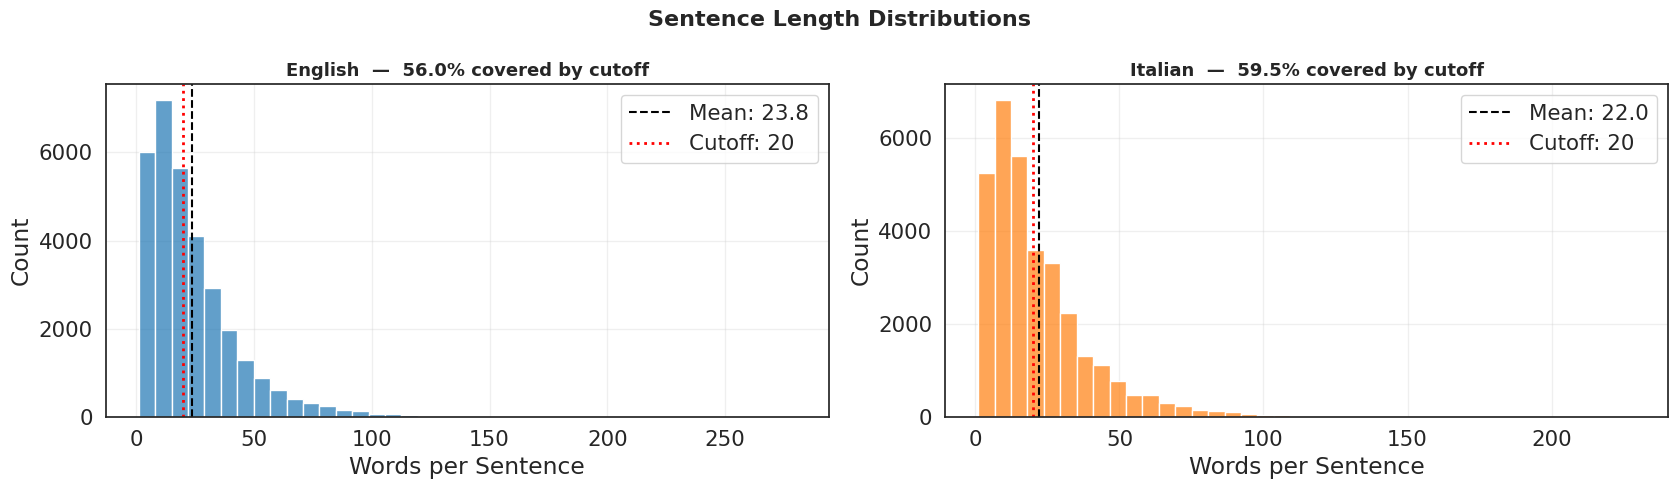

In [5]:
def plot_length_distributions(eng_lens: list, ita_lens: list) -> None:
    """
    Plot sentence length distributions with mean and sequence-length cutoff markers.

    The cutoff line shows what fraction of the corpus is fully covered by the
    chosen SEQ_LEN_SRC / SEQ_LEN_TGT values — useful for justifying the choice.

    Args:
        eng_lens: List of English sentence lengths (in words)
        ita_lens: List of Italian sentence lengths (in words)
    """
    COLOR_EN = '#1f77b4'
    COLOR_IT = '#ff7f0e'

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(17, 5))
    fig.suptitle('Sentence Length Distributions', fontsize=16, fontweight='bold')

    for ax, lens, lang, color, cutoff in [
        (ax1, eng_lens, 'English', COLOR_EN, SEQ_LEN_SRC),
        (ax2, ita_lens, 'Italian', COLOR_IT, SEQ_LEN_TGT - 2),  # -2 for BOS/EOS slots
    ]:
        sns.histplot(lens, ax=ax, color=color, alpha=0.7, bins=40)
        ax.axvline(np.mean(lens), color='black', linestyle='--', linewidth=1.5,
                   label=f'Mean: {np.mean(lens):.1f}')
        ax.axvline(cutoff, color='red', linestyle=':', linewidth=2.0,
                   label=f'Cutoff: {cutoff}')
        coverage = np.mean(np.array(lens) <= cutoff) * 100
        ax.set_title(f'{lang}  —  {coverage:.1f}% covered by cutoff',
                     fontsize=13, fontweight='bold')
        ax.set_xlabel('Words per Sentence')
        ax.set_ylabel('Count')
        ax.legend()
        ax.grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

plot_length_distributions(stats['eng_lens'], stats['ita_lens'])

In [6]:
# Display random samples from the corpus
print("\nRandom samples from corpus:")
for eng, ita in random.sample(pairs, 5):
    print(f"  EN: {eng}\n  IT: {ita}\n")


Random samples from corpus:
  EN: But another feeling had now taken the place of the jealousy: it was a wish that his wife's guilt should meet with retribution.
  IT: Ma questo sentimento si era trasformato in un altro: nel desiderio che non solo ella non avesse a trionfare, ma che della propria colpa dovesse sopportare la pena.

  EN: I looked at it; I smiled at the speaking likeness: I was absorbed and content.
  IT: Guardavo il ritratto e sorridevo. Ero assorta e contenta.

  EN: "Well, then, with Miss Temple you are good?"
  IT: — Allora con lei siete buona?

  EN: 'Oh, don't confuse matters!
  IT: — Via, non fate confusioni!

  EN: But if I can express at this distance the thoughts I had about me at that time, I was in tenfold more horror of mind upon account of my former convictions, and the having returned from them to the resolutions I had wickedly taken at first, than I was at death itself; and these, added to the terror of the storm, put me into such a condition that I can b

## Data Preprocessing

**1. BPE tokenisation** — Byte Pair Encoding splits words into frequent subword pieces, eliminating `<unk>` for rare words. A *shared* model is trained on the combined EN+IT corpus so cognates and named entities share the same ID in both languages.

    "untied"    →  ["▁un", "tied"]
    "slacciato" →  ["▁sl", "accia", "to"]

**2. Train / val / test split** — 70 / 15 / 15 %

**3. TranslationDataset** — pre-encodes every pair into three fixed-length tensors:
- `src`     — padded English source
- `tgt_in`  — Italian with BOS prepended (decoder input, teacher forcing)
- `tgt_out` — Italian with EOS appended  (prediction target)


In [7]:
# Special token indices — must match sentencepiece trainer arguments
PAD_IDX = 0   # Padding: ignored by loss and attention masks
BOS_IDX = 1   # Beginning of sequence: prepended to every decoder input
EOS_IDX = 2   # End of sequence: appended to every decoder target
UNK_IDX = 3   # Unknown: fallback for unseen pieces (rare with BPE)

BPE_MODEL_PREFIX = "bpe_shared"

In [8]:
def train_bpe(pairs: list[list[str]], model_prefix: str,
              vocab_size: int) -> spm.SentencePieceProcessor:
    """
    Train a shared BPE model on the combined source + target corpus.

    Training on both languages jointly maximises subword sharing for
    cognates and named entities that appear in both sides.
    The model is trained only on training pairs — val/test pairs are never
    seen, so there is no data leakage.

    Args:
        pairs:        List of [english, italian] training pairs
        model_prefix: Output path prefix (.model and .vocab files)
        vocab_size:   Target BPE vocabulary size

    Returns:
        Loaded SentencePieceProcessor ready for encoding/decoding
    """
    corpus_path = f"{model_prefix}_corpus.txt"
    with open(corpus_path, 'w', encoding='utf-8') as f:
        for eng, ita in pairs:
            f.write(eng.lower() + '\n')
            f.write(ita.lower() + '\n')

    spm.SentencePieceTrainer.train(
        input=corpus_path,
        model_prefix=model_prefix,
        vocab_size=vocab_size,
        pad_id=PAD_IDX,
        bos_id=BOS_IDX,
        eos_id=EOS_IDX,
        unk_id=UNK_IDX,
        character_coverage=0.9995,
        model_type='bpe',
        input_sentence_size=500000,
        shuffle_input_sentence=True,
    )

    sp = spm.SentencePieceProcessor()
    sp.load(f"{model_prefix}.model")
    print(f"BPE model trained  →  actual vocab size: {sp.get_piece_size():,}")
    return sp


def encode_bpe(sp: spm.SentencePieceProcessor, text: str,
               seq_len: int, add_bos: bool = False,
               add_eos: bool = False) -> list[int]:
    """
    Encode a raw text string to a fixed-length BPE integer sequence.

    Args:
        sp:       Trained SentencePieceProcessor
        text:     Raw input string (lowercased internally)
        seq_len:  Target output length (truncate then right-pad with PAD_IDX)
        add_bos:  Prepend BOS_IDX if True
        add_eos:  Append EOS_IDX if True

    Returns:
        List of integer BPE token IDs of exactly length seq_len
    """
    ids = sp.encode(text.lower(), out_type=int)
    if add_bos:
        ids = [BOS_IDX] + ids
    if add_eos:
        ids = ids + [EOS_IDX]
    ids = ids[:seq_len]
    ids += [PAD_IDX] * (seq_len - len(ids))
    return ids


def decode_bpe(sp: spm.SentencePieceProcessor, ids: list[int]) -> str:
    """Decode a list of BPE token IDs back to a readable string."""
    special = {PAD_IDX, BOS_IDX, EOS_IDX}
    return sp.decode([i for i in ids if i not in special])

In [9]:
# Shuffle before splitting (no stratification needed for seq2seq)
random.shuffle(pairs)
n_val   = int(0.15 * len(pairs))
n_test  = int(0.15 * len(pairs))
n_train = len(pairs) - n_val - n_test

train_pairs = pairs[:n_train]
val_pairs   = pairs[n_train : n_train + n_val]
test_pairs  = pairs[n_train + n_val :]

print(f"Dataset splits:\n"
      f"  Training:   {len(train_pairs):>8,d} pairs\n"
      f"  Validation: {len(val_pairs):>8,d} pairs\n"
      f"  Test:       {len(test_pairs):>8,d} pairs")

# Train BPE on training pairs only to prevent any form of data leakage
sp = train_bpe(train_pairs, BPE_MODEL_PREFIX, VOCAB_SIZE)
SHARED_VOCAB_SIZE = sp.get_piece_size()

Dataset splits:
  Training:     22,634 pairs
  Validation:    4,849 pairs
  Test:          4,849 pairs
BPE model trained  →  actual vocab size: 15,000


In [10]:
class TranslationDataset(Dataset):
    """
    PyTorch Dataset for English-Italian machine translation with BPE encoding.

    Pre-encodes all pairs at construction time; workers have zero encoding
    overhead at training time.

    Yields three tensors per pair:
      src     — encoded English source tokens
      tgt_in  — Italian with BOS prepended  (decoder input)
      tgt_out — Italian with EOS appended   (prediction target)
    """

    def __init__(self, pairs: list[list[str]], sp: spm.SentencePieceProcessor,
                 src_seq_len: int, tgt_seq_len: int):
        """
        Args:
            pairs:       List of [english, italian] string pairs
            sp:          Trained shared SentencePieceProcessor
            src_seq_len: Fixed length for source sequences
            tgt_seq_len: Fixed length for target sequences (includes BOS/EOS slot)
        """
        self.data = []
        for eng, ita in pairs:
            src     = encode_bpe(sp, eng, src_seq_len)
            tgt_in  = encode_bpe(sp, ita, tgt_seq_len, add_bos=True)
            tgt_out = encode_bpe(sp, ita, tgt_seq_len, add_eos=True)
            self.data.append((src, tgt_in, tgt_out))

    def __len__(self) -> int:
        return len(self.data)

    def __getitem__(self, idx: int) -> tuple[torch.Tensor, torch.Tensor, torch.Tensor]:
        src, tgt_in, tgt_out = self.data[idx]
        return (
            torch.tensor(src,     dtype=torch.long),
            torch.tensor(tgt_in,  dtype=torch.long),
            torch.tensor(tgt_out, dtype=torch.long),
        )


def make_loader(ds: Dataset, batch_size: int, shuffle: bool) -> DataLoader:
    """Create an optimised DataLoader for the translation dataset."""
    cpu_cores   = os.cpu_count() or 2
    num_workers = max(2, min(4, cpu_cores))
    return DataLoader(
        ds,
        batch_size=batch_size,
        shuffle=shuffle,
        num_workers=num_workers,
        pin_memory=True,
        pin_memory_device="cuda" if torch.cuda.is_available() else "",
        prefetch_factor=4,
        drop_last=False,
    )


train_ds = TranslationDataset(train_pairs, sp, SEQ_LEN_SRC, SEQ_LEN_TGT)
val_ds   = TranslationDataset(val_pairs,   sp, SEQ_LEN_SRC, SEQ_LEN_TGT)
test_ds  = TranslationDataset(test_pairs,  sp, SEQ_LEN_SRC, SEQ_LEN_TGT)

train_loader = make_loader(train_ds, BATCH_SIZE, shuffle=True)
val_loader   = make_loader(val_ds,   BATCH_SIZE, shuffle=False)
test_loader  = make_loader(test_ds,  BATCH_SIZE, shuffle=False)

src_b, tgt_in_b, tgt_out_b = next(iter(train_loader))
print(f"\nBatch tensor shapes:\n"
      f"  Source:         {src_b.shape}   (batch, src_seq_len)\n"
      f"  Decoder input:  {tgt_in_b.shape}  (batch, tgt_seq_len)\n"
      f"  Decoder target: {tgt_out_b.shape}  (batch, tgt_seq_len)")



Batch tensor shapes:
  Source:         torch.Size([256, 20])   (batch, src_seq_len)
  Decoder input:  torch.Size([256, 22])  (batch, tgt_seq_len)
  Decoder target: torch.Size([256, 22])  (batch, tgt_seq_len)


## Model Architecture

Encoder-decoder Transformer ([Vaswani et al., 2017](https://arxiv.org/abs/1706.03762)).  
All blocks use **Pre-Layer Normalisation** for improved gradient flow vs the original Post-LN.

| Component               | Config                     |
|-------------------------|----------------------------|
| Encoder / Decoder depth | 3 blocks                   |
| Embedding dimension *d* | 128                        |
| Attention heads         | 4                          |
| FFN hidden size         | 512 (4× *d*)               |
| Dropout                 | 0.1                        |
| Vocabulary              | 15 000 shared BPE tokens   |


### Positional Encoding

The Transformer processes tokens in parallel and has no built-in notion of order.  
Sinusoidal positional encoding injects position information by adding a fixed signal to each embedding:

$$PE_{(pos,\, 2i)}   = \sin\!\left(\frac{pos}{10000^{2i/d}}\right)$$
$$PE_{(pos,\, 2i+1)} = \cos\!\left(\frac{pos}{10000^{2i/d}}\right)$$

The matrix is precomputed once and stored as a non-trainable buffer.


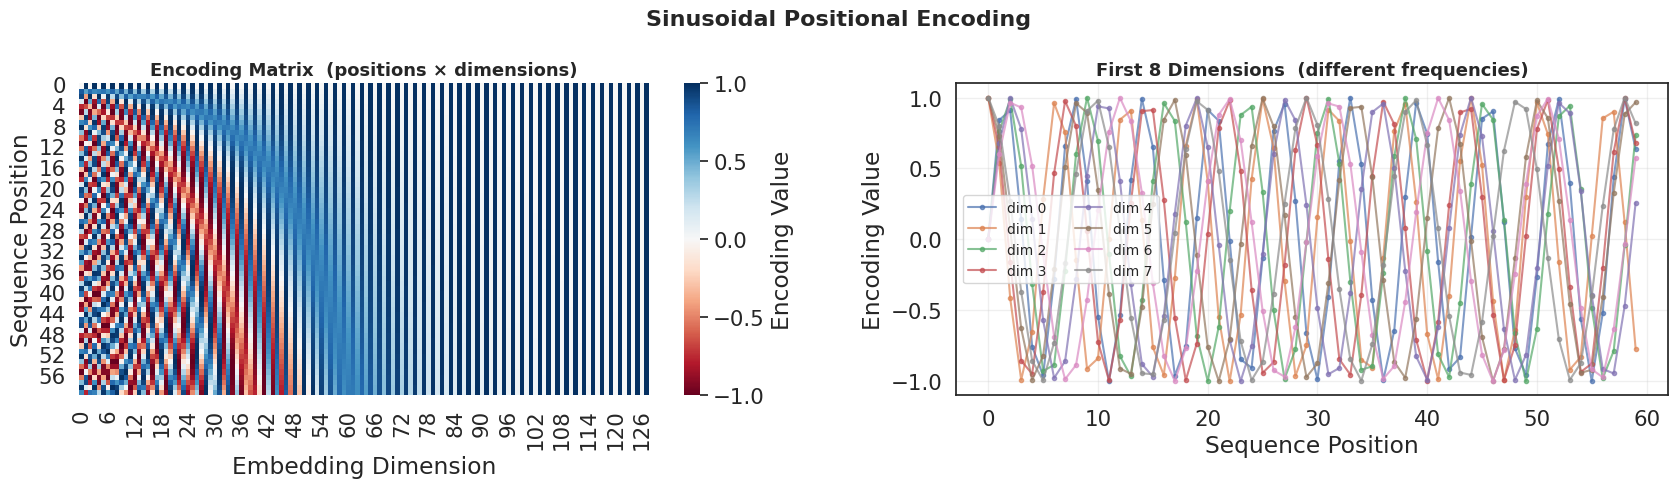

In [11]:
class PositionalEncoding(nn.Module):
    """
    Sinusoidal positional encoding as described in 'Attention Is All You Need'.

    Adds fixed, position-dependent signals to token embeddings so the model
    can reason about sequence order. The encoding matrix is precomputed and
    stored as a non-trainable buffer.
    """

    def __init__(self, embed_dim: int, max_len: int = 512, dropout: float = 0.1):
        """
        Args:
            embed_dim: Model dimension d_model
            max_len:   Maximum supported sequence length
            dropout:   Dropout applied after adding positional encoding
        """
        super().__init__()
        self.dropout = nn.Dropout(dropout)

        position = torch.arange(max_len).unsqueeze(1)
        div_term = torch.exp(
            torch.arange(0, embed_dim, 2) * (-math.log(10000.0) / embed_dim)
        )
        pe = torch.zeros(1, max_len, embed_dim)
        pe[0, :, 0::2] = torch.sin(position * div_term)
        pe[0, :, 1::2] = torch.cos(position * div_term)

        # Register as buffer: saved with model state but not a trainable parameter
        self.register_buffer('pe', pe)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        Add positional encoding to token embeddings.

        Args:
            x: Token embeddings (batch, seq_len, embed_dim)

        Returns:
            Positionally-encoded tensor of identical shape
        """
        x = x + self.pe[:, :x.size(1), :]
        return self.dropout(x)


def plot_positional_encoding(embed_dim: int, max_len: int = 60) -> None:
    """
    Visualise the sinusoidal positional encoding matrix and its first dimensions.

    Left panel: full (positions × dimensions) heatmap — shows the
    characteristic chessboard-like pattern of alternating sine/cosine waves.

    Right panel: oscillation curves of the first 8 dimensions — shows that
    lower dimensions oscillate at high frequency (fine-grained position) while
    higher dimensions oscillate slowly (coarse position), giving the model a
    multi-scale positional signal.

    Args:
        embed_dim: Model embedding dimension
        max_len:   Number of positions to visualise
    """
    position = np.arange(max_len)[:, np.newaxis]
    div_term = np.exp(np.arange(0, embed_dim, 2) * (-np.log(10000.0) / embed_dim))
    pe = np.zeros((max_len, embed_dim))
    pe[:, 0::2] = np.sin(position * div_term)
    pe[:, 1::2] = np.cos(position * div_term)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(17, 5))
    fig.suptitle('Sinusoidal Positional Encoding', fontsize=16, fontweight='bold')

    sns.heatmap(pe, ax=ax1, cmap='RdBu', center=0, vmin=-1, vmax=1,
                cbar_kws={'label': 'Encoding Value'})
    ax1.set_title('Encoding Matrix  (positions × dimensions)', fontsize=13,
                  fontweight='bold')
    ax1.set_xlabel('Embedding Dimension')
    ax1.set_ylabel('Sequence Position')

    for i in range(8):
        ax2.plot(pe[:, i], label=f'dim {i}', marker='o', markersize=3, alpha=0.7)
    ax2.set_title('First 8 Dimensions  (different frequencies)', fontsize=13,
                  fontweight='bold')
    ax2.set_xlabel('Sequence Position')
    ax2.set_ylabel('Encoding Value')
    ax2.legend(ncol=2, fontsize=10)
    ax2.grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

plot_positional_encoding(EMBED_DIM)

### Encoder Block

Each block applies two Pre-LN sub-layers:

$$x = x + \text{MHA}(\text{LN}(x))$$
$$x = x + \text{FFN}(\text{LN}(x))$$

Attention weights are cached in `last_attn_weights` after each forward pass for later visualisation.


In [12]:
class TransformerEncoderBlock(nn.Module):
    """
    Single Transformer encoder block with Pre-Layer Normalisation (Pre-LN).

    Self-attention lets every source token attend to every other source token,
    building contextualised representations. Attention weights are stored for
    visualisation after each forward pass.
    """

    def __init__(self, embed_dim: int, ffn_dim: int,
                 num_heads: int, dropout: float = 0.1):
        """
        Args:
            embed_dim: Model dimension (must be divisible by num_heads)
            ffn_dim:   Feed-forward hidden dimension
            num_heads: Number of parallel attention heads
            dropout:   Dropout probability
        """
        super().__init__()

        self.self_attn = nn.MultiheadAttention(
            embed_dim=embed_dim, num_heads=num_heads,
            dropout=dropout, batch_first=True
        )
        self.ffn = nn.Sequential(
            nn.Linear(embed_dim, ffn_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(ffn_dim, embed_dim),
            nn.Dropout(dropout),
        )
        self.norm1 = nn.LayerNorm(embed_dim)
        self.norm2 = nn.LayerNorm(embed_dim)

        # Populated after each forward pass; used only for visualisation
        self.last_attn_weights: Optional[torch.Tensor] = None

    def forward(self, x: torch.Tensor,
                src_key_padding_mask: Optional[torch.Tensor] = None) -> torch.Tensor:
        """
        Args:
            x:                    Input tensor (batch, src_len, embed_dim)
            src_key_padding_mask: Boolean PAD mask (batch, src_len); True = ignore

        Returns:
            Contextualised tensor of same shape as input
        """
        # Pre-norm self-attention + residual
        normed = self.norm1(x)
        attn_out, attn_w = self.self_attn(
            normed, normed, normed,
            key_padding_mask=src_key_padding_mask,
            need_weights=True,
            average_attn_weights=False    # Retain per-head: (batch, heads, seq, seq)
        )
        self.last_attn_weights = attn_w.detach()
        x = x + attn_out

        # Pre-norm FFN + residual
        x = x + self.ffn(self.norm2(x))
        return x

### Decoder Block

Three Pre-LN sub-layers per block:

$$x = x + \text{MaskedMHA}(\text{LN}(x))$$
$$x = x + \text{CrossMHA}(\text{LN}(x),\;\text{memory})$$
$$x = x + \text{FFN}(\text{LN}(x))$$

The **causal mask** in MaskedMHA enforces the autoregressive constraint (position *t* attends only to positions ≤ *t*).  
The **cross-attention** over encoder memory is the alignment mechanism and the primary visualisation target.


In [13]:
class TransformerDecoderBlock(nn.Module):
    """
    Single Transformer decoder block with Pre-Layer Normalisation (Pre-LN).

    Contains three sub-layers:
      1. Masked self-attention  — causal, prevents attending to future positions
      2. Cross-attention        — attends to encoder memory (the alignment layer)
      3. Feed-forward network

    Both self-attention and cross-attention weights are stored after each
    forward pass for visualisation.
    """

    def __init__(self, embed_dim: int, ffn_dim: int,
                 num_heads: int, dropout: float = 0.1):
        """
        Args:
            embed_dim: Model dimension
            ffn_dim:   Feed-forward hidden dimension
            num_heads: Number of parallel attention heads
            dropout:   Dropout probability
        """
        super().__init__()

        self.self_attn = nn.MultiheadAttention(
            embed_dim=embed_dim, num_heads=num_heads,
            dropout=dropout, batch_first=True
        )
        self.cross_attn = nn.MultiheadAttention(
            embed_dim=embed_dim, num_heads=num_heads,
            dropout=dropout, batch_first=True
        )
        self.ffn = nn.Sequential(
            nn.Linear(embed_dim, ffn_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(ffn_dim, embed_dim),
            nn.Dropout(dropout),
        )
        self.norm1 = nn.LayerNorm(embed_dim)
        self.norm2 = nn.LayerNorm(embed_dim)
        self.norm3 = nn.LayerNorm(embed_dim)

        self.last_self_attn_weights:  Optional[torch.Tensor] = None
        self.last_cross_attn_weights: Optional[torch.Tensor] = None

    def forward(self, x: torch.Tensor, memory: torch.Tensor,
                tgt_mask: Optional[torch.Tensor] = None,
                tgt_key_padding_mask: Optional[torch.Tensor] = None,
                memory_key_padding_mask: Optional[torch.Tensor] = None) -> torch.Tensor:
        """
        Args:
            x:                       Decoder input (batch, tgt_len, embed_dim)
            memory:                  Encoder output (batch, src_len, embed_dim)
            tgt_mask:                Causal mask (tgt_len, tgt_len)
            tgt_key_padding_mask:    PAD mask for decoder input (batch, tgt_len)
            memory_key_padding_mask: PAD mask for encoder output (batch, src_len)

        Returns:
            Decoded tensor of same shape as x
        """
        # 1. Pre-norm masked self-attention + residual
        normed = self.norm1(x)
        sa_out, sa_w = self.self_attn(
            normed, normed, normed,
            attn_mask=tgt_mask,
            key_padding_mask=tgt_key_padding_mask,
            need_weights=True,
            average_attn_weights=False
        )
        self.last_self_attn_weights = sa_w.detach()
        x = x + sa_out

        # 2. Pre-norm cross-attention over encoder memory + residual
        normed = self.norm2(x)
        ca_out, ca_w = self.cross_attn(
            normed, memory, memory,
            key_padding_mask=memory_key_padding_mask,
            need_weights=True,
            average_attn_weights=False    # (batch, heads, tgt_len, src_len)
        )
        self.last_cross_attn_weights = ca_w.detach()
        x = x + ca_out

        # 3. Pre-norm FFN + residual
        x = x + self.ffn(self.norm3(x))
        return x

### Seq2Seq Transformer

The full model exposes separate `encode()` and `decode()` methods: during autoregressive inference the encoder runs **once**, and `decode()` is called step-by-step reusing the same memory tensor.

- Embeddings are scaled by √*d_model* (Section 3.4 of the paper)  
- All weight matrices are initialised with Xavier uniform


In [14]:
class Seq2SeqTransformer(nn.Module):
    """
    Full encoder-decoder Transformer for sequence-to-sequence translation.

    Encoder: source embedding → positional encoding → EncoderBlock stack
    Decoder: target embedding → positional encoding → DecoderBlock stack
    Output:  linear projection → target vocabulary logits

    The shared BPE vocabulary means src and tgt use vocabularies of the
    same size, though their embedding matrices remain independent.
    """

    def __init__(self, src_vocab_size: int, tgt_vocab_size: int,
                 embed_dim: int, ffn_dim: int, num_heads: int,
                 num_enc_layers: int, num_dec_layers: int,
                 src_seq_len: int, tgt_seq_len: int,
                 dropout: float = 0.1):
        super().__init__()

        self.src_embedding  = nn.Embedding(src_vocab_size, embed_dim,
                                           padding_idx=PAD_IDX)
        self.src_pos_enc    = PositionalEncoding(embed_dim,
                                                  max_len=src_seq_len + 10,
                                                  dropout=dropout)
        self.encoder_blocks = nn.ModuleList([
            TransformerEncoderBlock(embed_dim, ffn_dim, num_heads, dropout)
            for _ in range(num_enc_layers)
        ])

        self.tgt_embedding  = nn.Embedding(tgt_vocab_size, embed_dim,
                                           padding_idx=PAD_IDX)
        self.tgt_pos_enc    = PositionalEncoding(embed_dim,
                                                  max_len=tgt_seq_len + 10,
                                                  dropout=dropout)
        self.decoder_blocks = nn.ModuleList([
            TransformerDecoderBlock(embed_dim, ffn_dim, num_heads, dropout)
            for _ in range(num_dec_layers)
        ])

        self.output_projection = nn.Linear(embed_dim, tgt_vocab_size)

        # Embedding scaling factor: multiply by sqrt(d_model) per original paper §3.4
        self.embed_scale = math.sqrt(embed_dim)

        self._init_weights()

    def _init_weights(self) -> None:
        """Xavier uniform initialisation for all weight matrices; biases to zero."""
        for p in self.parameters():
            if p.dim() > 1:
                nn.init.xavier_uniform_(p)

    def encode(self, src: torch.Tensor,
               src_key_padding_mask: Optional[torch.Tensor] = None) -> torch.Tensor:
        """
        Run source tokens through the full encoder stack.

        Args:
            src:                  Source token indices (batch, src_len)
            src_key_padding_mask: PAD mask (batch, src_len)

        Returns:
            Encoder memory (batch, src_len, embed_dim)
        """
        x = self.src_pos_enc(self.src_embedding(src) * self.embed_scale)
        for block in self.encoder_blocks:
            x = block(x, src_key_padding_mask=src_key_padding_mask)
        return x

    def decode(self, tgt: torch.Tensor, memory: torch.Tensor,
               tgt_mask: Optional[torch.Tensor] = None,
               tgt_key_padding_mask: Optional[torch.Tensor] = None,
               memory_key_padding_mask: Optional[torch.Tensor] = None) -> torch.Tensor:
        """
        Run target tokens through the full decoder stack, attending to memory.

        Args:
            tgt:                     Target token indices (batch, tgt_len)
            memory:                  Encoder output (batch, src_len, embed_dim)
            tgt_mask:                Causal mask (tgt_len, tgt_len)
            tgt_key_padding_mask:    Target PAD mask (batch, tgt_len)
            memory_key_padding_mask: Source PAD mask (batch, src_len)

        Returns:
            Decoded feature tensor (batch, tgt_len, embed_dim)
        """
        x = self.tgt_pos_enc(self.tgt_embedding(tgt) * self.embed_scale)
        for block in self.decoder_blocks:
            x = block(x, memory,
                      tgt_mask=tgt_mask,
                      tgt_key_padding_mask=tgt_key_padding_mask,
                      memory_key_padding_mask=memory_key_padding_mask)
        return x

    def forward(self, src: torch.Tensor, tgt: torch.Tensor) -> torch.Tensor:
        """
        Full forward pass for teacher-forced training.

        Args:
            src: Source token indices (batch, src_len)
            tgt: Target token indices with BOS prepended (batch, tgt_len)

        Returns:
            Logits over target vocabulary (batch, tgt_len, tgt_vocab_size)
        """
        src_pad_mask = (src == PAD_IDX)
        tgt_pad_mask = (tgt == PAD_IDX)
        tgt_causal_mask = nn.Transformer.generate_square_subsequent_mask(
            tgt.size(1), device=tgt.device
        )
        memory  = self.encode(src, src_key_padding_mask=src_pad_mask)
        decoded = self.decode(tgt, memory,
                              tgt_mask=tgt_causal_mask,
                              tgt_key_padding_mask=tgt_pad_mask,
                              memory_key_padding_mask=src_pad_mask)
        return self.output_projection(decoded)

In [15]:
# Instantiate and move to device
model = Seq2SeqTransformer(
    src_vocab_size=SHARED_VOCAB_SIZE,
    tgt_vocab_size=SHARED_VOCAB_SIZE,
    embed_dim=EMBED_DIM,
    ffn_dim=FFN_DIM,
    num_heads=NUM_HEADS,
    num_enc_layers=NUM_ENC_LAYERS,
    num_dec_layers=NUM_DEC_LAYERS,
    src_seq_len=SEQ_LEN_SRC,
    tgt_seq_len=SEQ_LEN_TGT,
    dropout=DROPOUT_RATE,
).to(device)

total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Model parameters:\n"
      f"  Total:     {total_params:>10,d}\n"
      f"  Trainable: {trainable_params:>10,d}")

Model parameters:
  Total:      7,163,544
  Trainable:  7,163,544



Component                 Type                              Trainable        Total       %
──────────────────────────────────────────────────────────────────────────────────────────
src_embedding             Embedding                         1,920,000    1,920,000   26.8%
src_pos_enc               PositionalEncoding                        0            0    0.0%
encoder_blocks            ModuleList                          594,816      594,816    8.3%
tgt_embedding             Embedding                         1,920,000    1,920,000   26.8%
tgt_pos_enc               PositionalEncoding                        0            0    0.0%
decoder_blocks            ModuleList                          793,728      793,728   11.1%
output_projection         Linear                            1,935,000    1,935,000   27.0%
──────────────────────────────────────────────────────────────────────────────────────────
TOTAL                                                       7,163,544    7,163,544  100.0

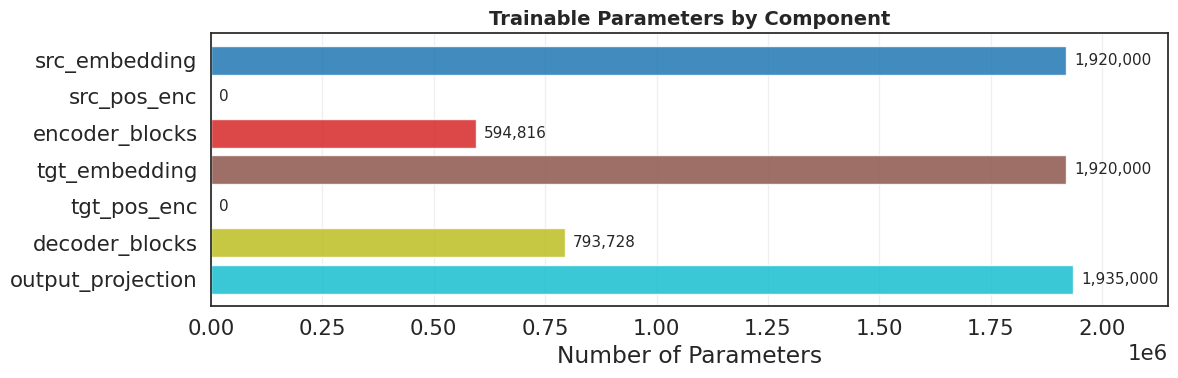

In [16]:
def plot_parameter_breakdown(model: nn.Module) -> None:
    """
    Print and plot parameter count broken down by top-level component.

    Args:
        model: Seq2SeqTransformer to analyse
    """
    rows = []
    for name, module in model.named_children():
        total     = sum(p.numel() for p in module.parameters())
        trainable = sum(p.numel() for p in module.parameters() if p.requires_grad)
        rows.append((name, type(module).__name__, trainable, total))

    grand_total     = sum(p.numel() for p in model.parameters())
    grand_trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)

    print(f"\n{'Component':<25} {'Type':<30} {'Trainable':>12} {'Total':>12} {'%':>7}")
    print('─' * 90)
    for name, typ, train, tot in rows:
        print(f"{name:<25} {typ:<30} {train:>12,} {tot:>12,} {tot/grand_total*100:>6.1f}%")
    print('─' * 90)
    print(f"{'TOTAL':<25} {'':<30} {grand_trainable:>12,} {grand_total:>12,} {'100.0%':>7}")

    names  = [r[0] for r in rows]
    counts = [r[2] for r in rows]
    colors = plt.cm.tab10(np.linspace(0, 1, len(names)))

    fig, ax = plt.subplots(figsize=(12, 4))
    bars = ax.barh(names, counts, color=colors, alpha=0.85)
    ax.bar_label(bars, labels=[f'{c:,}' for c in counts], padding=6, fontsize=11)
    ax.set_xlim(0, max(counts) * 1.11)

    ax.set_title('Trainable Parameters by Component', fontsize=14, fontweight='bold')
    ax.set_xlabel('Number of Parameters')
    ax.grid(alpha=0.3, axis='x')
    ax.invert_yaxis()
    plt.tight_layout()
    plt.show()

plot_parameter_breakdown(model)

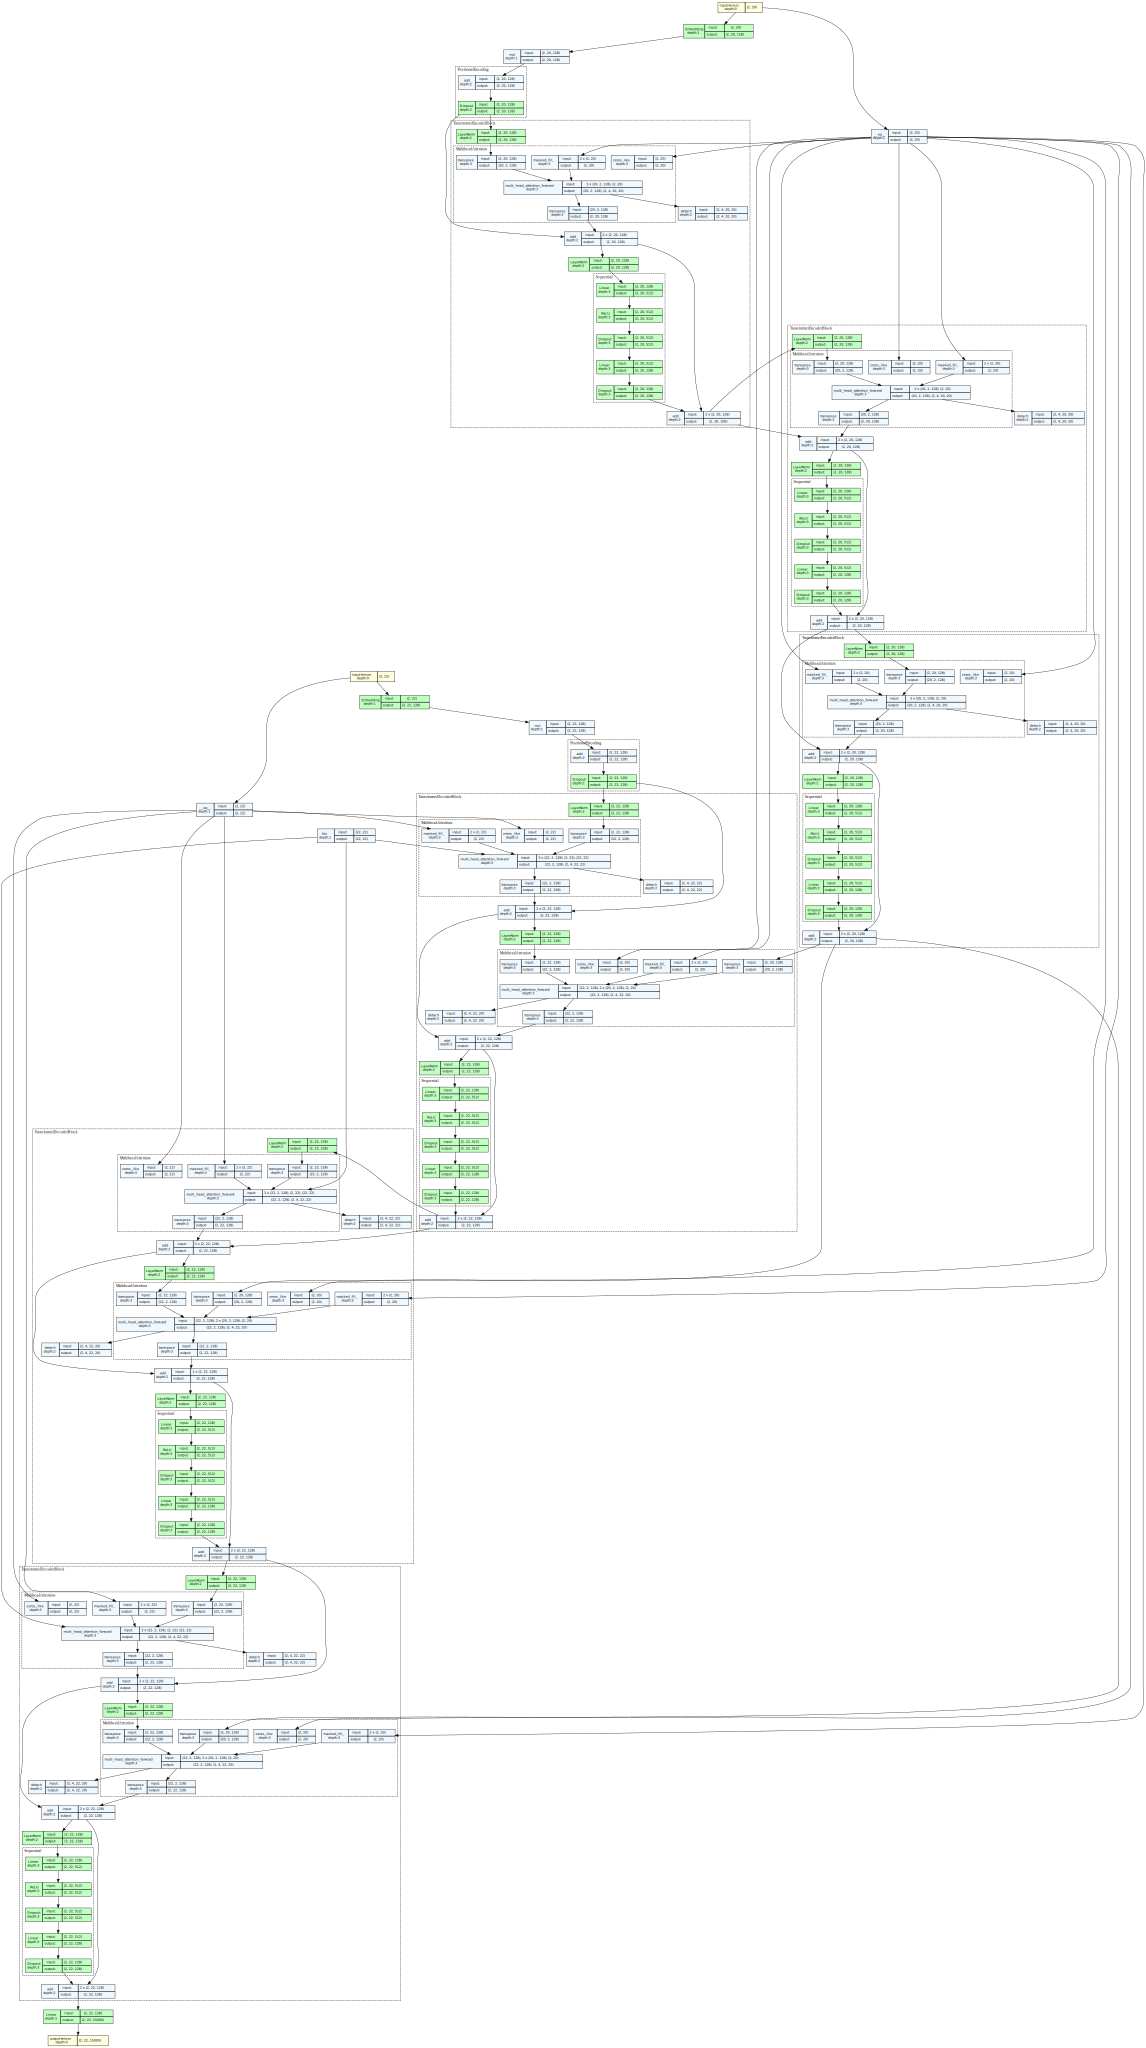

In [43]:
# Computational graph
dummy_src = torch.randint(0, SHARED_VOCAB_SIZE, (2, SEQ_LEN_SRC)).to(device)
dummy_tgt = torch.randint(0, SHARED_VOCAB_SIZE, (2, SEQ_LEN_TGT)).to(device)

model_graph = draw_graph(
    model,
    input_data=(dummy_src, dummy_tgt),
    expand_nested=True,
    depth=4,
    device=device.type
)
model_graph.visual_graph

##  Training Setup

| Setting | Value | Notes |
|---------|-------|-------|
| Loss | CrossEntropy + label smoothing ε = 0.1 | penalises overconfident outputs |
| Optimiser | Adam β₁=0.9, β₂=0.98, ε=1e-9 | exact paper config |
| LR schedule | warmup (4 k steps) → inverse-√ decay | paper-exact |
| Mixed precision | `autocast` + `GradScaler` | ~1.5–2× speedup on T4/A100 |
| Gradient clipping | max norm = 1.0 | stabilises late training |
| Early stopping | patience = 10 epochs | restores best weights |


In [18]:
criterion = nn.CrossEntropyLoss(ignore_index=PAD_IDX, label_smoothing=LABEL_SMOOTHING)
optimizer = torch.optim.Adam(model.parameters(), lr=1.0, betas=(0.9, 0.98), eps=1e-9)

def warmup_lr_lambda(step: int) -> float:
    """
    Transformer LR schedule from 'Attention Is All You Need'.

    Increases linearly for the first warmup_steps, then decays as step^{-0.5}.
    Setting the optimiser lr=1.0 and applying this lambda achieves the correct
    absolute scale.

    Args:
        step: Current optimiser step (1-indexed)

    Returns:
        LR multiplier applied by the scheduler
    """
    step = max(step, 1)
    return (EMBED_DIM ** -0.5) * min(step ** -0.5, step * WARMUP_STEPS ** -1.5)


# Step-based scheduler — must be called once per batch, not per epoch
scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, warmup_lr_lambda)

# Mixed precision gradient scaler (no-op on CPU)
scaler = torch.amp.GradScaler(enabled=(device.type == 'cuda'))

print(f"Training configuration:\n"
      f"  Loss:            CrossEntropyLoss  (label_smoothing={LABEL_SMOOTHING})\n"
      f"  Optimiser:       Adam  (β₁=0.9, β₂=0.98, ε=1e-9)\n"
      f"  LR schedule:     Warmup ({WARMUP_STEPS} steps) + inverse sqrt decay\n"
      f"  Mixed precision: {device.type == 'cuda'}\n"
      f"  Grad clipping:   max_norm={CLIP_GRAD}")

Training configuration:
  Loss:            CrossEntropyLoss  (label_smoothing=0.1)
  Optimiser:       Adam  (β₁=0.9, β₂=0.98, ε=1e-9)
  LR schedule:     Warmup (4000 steps) + inverse sqrt decay
  Mixed precision: True
  Grad clipping:   max_norm=1.0


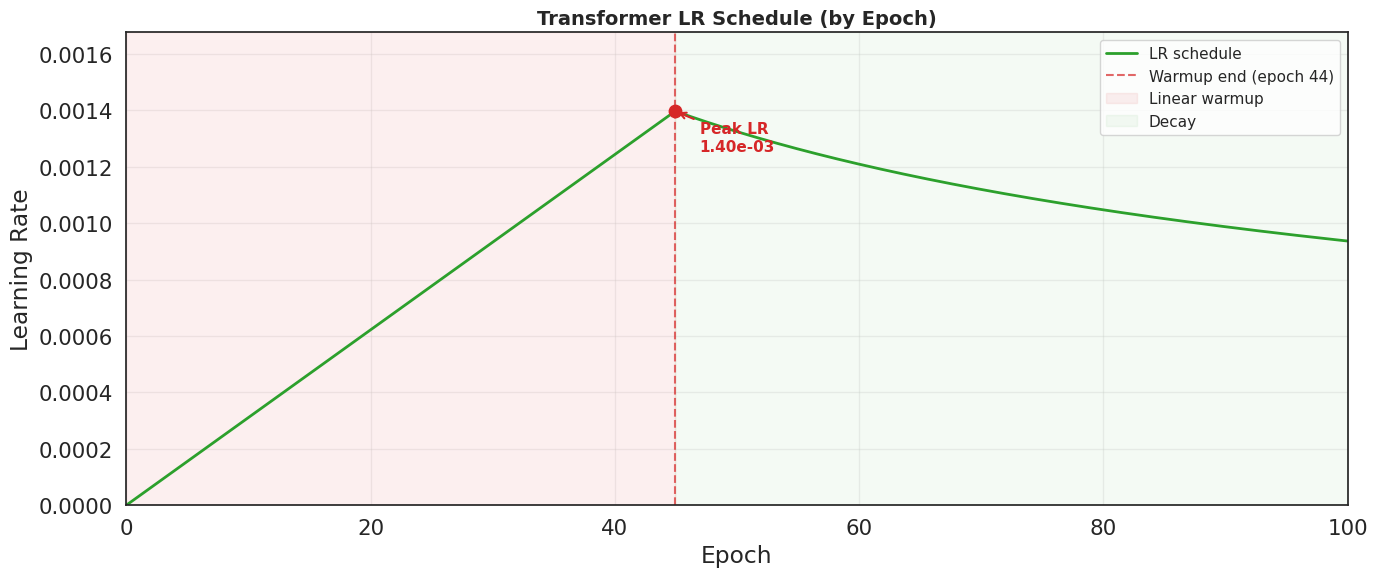

In [19]:
def plot_lr_schedule(embed_dim: int, warmup_steps: int, train_loader: DataLoader,
                     total_epochs: int = 50) -> None:
    """
    Plot the theoretical Transformer LR schedule converted to epochs.

    Args:
        embed_dim:    Model dimension (d_model)
        warmup_steps: Number of linear warmup steps
        train_loader: Used to calculate steps per epoch
        total_epochs: Number of epochs to visualise
    """
    steps_per_epoch = len(train_loader)
    total_steps = total_epochs * steps_per_epoch
    steps = np.arange(1, total_steps + 1)

    # Calculate LR based on steps
    lrs = (embed_dim ** -0.5) * np.minimum(
        steps ** -0.5,
        steps * warmup_steps ** -1.5
    )

    # Convert steps to epoch decimals for the plot
    epochs_axis = steps / steps_per_epoch
    warmup_epoch = warmup_steps / steps_per_epoch

    fig, ax = plt.subplots(figsize=(14, 6))

    ax.plot(epochs_axis, lrs, color='#2ca02c', linewidth=2, label='LR schedule')

    # Mark the warmup boundary
    peak_lr = lrs[warmup_steps - 1]
    ax.axvline(warmup_epoch, color='#d62728', linestyle='--', alpha=0.7,
               label=f'Warmup end (epoch {int(warmup_epoch)})')
    ax.scatter([warmup_epoch], [peak_lr], color='#d62728', s=80, zorder=5)

    # Adjust text position and increase y-limit to avoid clipping
    ax.annotate(f'Peak LR\n{peak_lr:.2e}',
                xy=(warmup_epoch, peak_lr),
                xytext=(warmup_epoch + total_epochs * 0.02, peak_lr * 0.9),
                fontsize=11, color='#d62728', fontweight='bold',
                arrowprops=dict(arrowstyle='->', color='#d62728', lw=1.5))

    # Shade the two phases
    ax.axvspan(0, warmup_epoch, alpha=0.07, color='#d62728', label='Linear warmup')
    ax.axvspan(warmup_epoch, total_epochs, alpha=0.05, color='#2ca02c', label='Decay')

    ax.set_title(f'Transformer LR Schedule (by Epoch)', fontsize=14, fontweight='bold')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Learning Rate')

    # Increase top margin to ensure Peak LR label is inside
    ax.set_ylim(0, peak_lr * 1.2)
    ax.set_xlim(0, total_epochs)

    ax.legend(fontsize=11, loc='upper right')
    ax.grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

# Calculate and plot
plot_lr_schedule(EMBED_DIM, WARMUP_STEPS, train_loader, total_epochs=EPOCHS)

## **Model Training**

In [20]:
def train_one_epoch(model: nn.Module, loader: DataLoader,
                    criterion: nn.Module, optimizer: torch.optim.Optimizer,
                    scaler: torch.amp.GradScaler, scheduler,
                    device: torch.device) -> tuple[float, float]:
    """
    Perform one training epoch with teacher forcing and step-based LR update.

    Args:
        model:     Seq2SeqTransformer
        loader:    Training DataLoader (yields src, tgt_in, tgt_out)
        criterion: CrossEntropyLoss with ignore_index=PAD_IDX
        optimizer: Adam optimiser
        scaler:    Mixed precision gradient scaler
        scheduler: Step-based LR scheduler (stepped once per batch)
        device:    Computation device

    Returns:
        Tuple of (average_loss, token_accuracy) — accuracy excludes PAD tokens
    """
    model.train()
    running_loss               = 0.0
    correct_tokens, total_tokens = 0, 0

    for src, tgt_in, tgt_out in loader:
        src, tgt_in, tgt_out = src.to(device), tgt_in.to(device), tgt_out.to(device)

        optimizer.zero_grad(set_to_none=True)

        with torch.amp.autocast(device_type=device.type, enabled=(device.type == 'cuda')):
            logits = model(src, tgt_in)
            loss   = criterion(
                logits.reshape(-1, logits.size(-1)),
                tgt_out.reshape(-1)
            )

        scaler.scale(loss).backward()

        # Unscale before clipping so the norm is measured in full precision
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), CLIP_GRAD)

        scaler.step(optimizer)
        scaler.update()
        scheduler.step()    # Step-based — called once per batch

        running_loss   += loss.item() * src.size(0)
        non_pad         = tgt_out != PAD_IDX
        preds           = logits.argmax(dim=-1)
        correct_tokens += (preds[non_pad] == tgt_out[non_pad]).sum().item()
        total_tokens   += non_pad.sum().item()

    return running_loss / len(loader.dataset), correct_tokens / max(total_tokens, 1)

In [21]:
def validate_one_epoch(model: nn.Module, loader: DataLoader,
                       criterion: nn.Module,
                       device: torch.device) -> tuple[float, float]:
    """
    Evaluate model on a validation set for one epoch.

    Args:
        model:     Seq2SeqTransformer (set to eval mode internally)
        loader:    Validation DataLoader
        criterion: Loss function
        device:    Computation device

    Returns:
        Tuple of (average_loss, token_accuracy)
    """
    model.eval()
    running_loss               = 0.0
    correct_tokens, total_tokens = 0, 0

    with torch.no_grad():
        for src, tgt_in, tgt_out in loader:
            src, tgt_in, tgt_out = src.to(device), tgt_in.to(device), tgt_out.to(device)

            with torch.amp.autocast(device_type=device.type,
                                    enabled=(device.type == 'cuda')):
                logits = model(src, tgt_in)
                loss   = criterion(
                    logits.reshape(-1, logits.size(-1)),
                    tgt_out.reshape(-1)
                )

            running_loss   += loss.item() * src.size(0)
            non_pad         = tgt_out != PAD_IDX
            preds           = logits.argmax(dim=-1)
            correct_tokens += (preds[non_pad] == tgt_out[non_pad]).sum().item()
            total_tokens   += non_pad.sum().item()

    return running_loss / len(loader.dataset), correct_tokens / max(total_tokens, 1)

In [22]:
def fit(model: nn.Module, train_loader: DataLoader, val_loader: DataLoader,
        epochs: int, criterion: nn.Module, optimizer: torch.optim.Optimizer,
        scaler: torch.amp.GradScaler, scheduler, device: torch.device,
        patience: int = 10, verbose: int = 1,
        experiment_name: str = "") -> tuple[nn.Module, dict]:
    """
    Full training loop with early stopping on validation loss and
    best-weight restoration.

    Monitors val_loss (lower is better). Best weights are saved to disk
    and automatically restored at the end of training.

    Args:
        model:           Seq2SeqTransformer to train
        train_loader:    Training DataLoader
        val_loader:      Validation DataLoader
        epochs:          Maximum number of training epochs
        criterion:       Loss function
        optimizer:       Optimiser
        scaler:          Mixed precision gradient scaler
        scheduler:       Step-based LR scheduler
        device:          Computation device
        patience:        Epochs without improvement before early stopping
        verbose:         Print progress every N epochs (0 = silent)
        experiment_name: Prefix for the saved weights file

    Returns:
        Tuple of (best_model, history_dict) where history_dict contains
        per-epoch lists: train_loss, val_loss, train_acc, val_acc, lr
    """
    history = {'train_loss': [], 'val_loss': [],
               'train_acc':  [], 'val_acc':  [],
               'lr':         []}

    best_val_loss    = float('inf')
    best_weights     = None
    patience_counter = 0

    for epoch in range(1, epochs + 1):
        train_loss, train_acc = train_one_epoch(
            model, train_loader, criterion, optimizer, scaler, scheduler, device
        )
        val_loss, val_acc = validate_one_epoch(model, val_loader, criterion, device)
        current_lr = scheduler.get_last_lr()[0]

        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['train_acc'].append(train_acc)
        history['val_acc'].append(val_acc)
        history['lr'].append(current_lr)

        if val_loss < best_val_loss:
            best_val_loss    = val_loss
            best_weights     = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            patience_counter = 0
            if experiment_name:
                torch.save(best_weights, f'models/{experiment_name}_best.pt')
        else:
            patience_counter += 1

        if verbose > 0 and (epoch % verbose == 0 or epoch == 1):
            print(f"Epoch {epoch:3d}/{epochs} | "
                  f"Train Loss: {train_loss:.4f}, Acc: {train_acc:.4f} | "
                  f"Val Loss: {val_loss:.4f}, Acc: {val_acc:.4f} | "
                  f"LR: {current_lr:.2e}")

        if patience_counter >= patience:
            print(f"\nEarly stopping at epoch {epoch} "
                  f"(no val_loss improvement for {patience} epochs)")
            break

    if best_weights is not None:
        model.load_state_dict({k: v.to(device) for k, v in best_weights.items()})
        print(f"Best weights restored  (val_loss = {best_val_loss:.4f})")

    return model, history

In [23]:
# Set to True to train from scratch or False to load pre-saved weights
TRAIN_FROM_SCRATCH = True

experiment_name = "transformer_nmt"

In [24]:
%%time
if TRAIN_FROM_SCRATCH:
    model, history = fit(
        model=model,
        train_loader=train_loader,
        val_loader=val_loader,
        epochs=EPOCHS,
        criterion=criterion,
        optimizer=optimizer,
        scaler=scaler,
        scheduler=scheduler,
        device=device,
        patience=PATIENCE,
        verbose=1,
        experiment_name=experiment_name,
    )
    torch.save(history, f'models/{experiment_name}_history.pt')
else:
    model.load_state_dict(
        torch.load(f'models/{experiment_name}_best.pt', map_location=device)
    )
    history = torch.load(f'models/{experiment_name}_history.pt')
    print("Pre-trained model and history loaded.")

Epoch   1/100 | Train Loss: 9.3712, Acc: 0.0337 | Val Loss: 8.5362, Acc: 0.0586 | LR: 3.11e-05
Epoch   2/100 | Train Loss: 7.5576, Acc: 0.0633 | Val Loss: 7.2307, Acc: 0.0722 | LR: 6.22e-05
Epoch   3/100 | Train Loss: 7.1888, Acc: 0.0818 | Val Loss: 7.1417, Acc: 0.0852 | LR: 9.33e-05
Epoch   4/100 | Train Loss: 7.0271, Acc: 0.1065 | Val Loss: 6.8564, Acc: 0.1251 | LR: 1.24e-04
Epoch   5/100 | Train Loss: 6.7032, Acc: 0.1356 | Val Loss: 6.5179, Acc: 0.1491 | LR: 1.55e-04
Epoch   6/100 | Train Loss: 6.4144, Acc: 0.1512 | Val Loss: 6.2789, Acc: 0.1626 | LR: 1.87e-04
Epoch   7/100 | Train Loss: 6.1950, Acc: 0.1647 | Val Loss: 6.1118, Acc: 0.1724 | LR: 2.18e-04
Epoch   8/100 | Train Loss: 6.0152, Acc: 0.1769 | Val Loss: 5.9761, Acc: 0.1826 | LR: 2.49e-04
Epoch   9/100 | Train Loss: 5.8618, Acc: 0.1881 | Val Loss: 5.8575, Acc: 0.1928 | LR: 2.80e-04
Epoch  10/100 | Train Loss: 5.7204, Acc: 0.1990 | Val Loss: 5.7555, Acc: 0.2032 | LR: 3.11e-04
Epoch  11/100 | Train Loss: 5.5854, Acc: 0.2108 | 

## **Plot Training History**

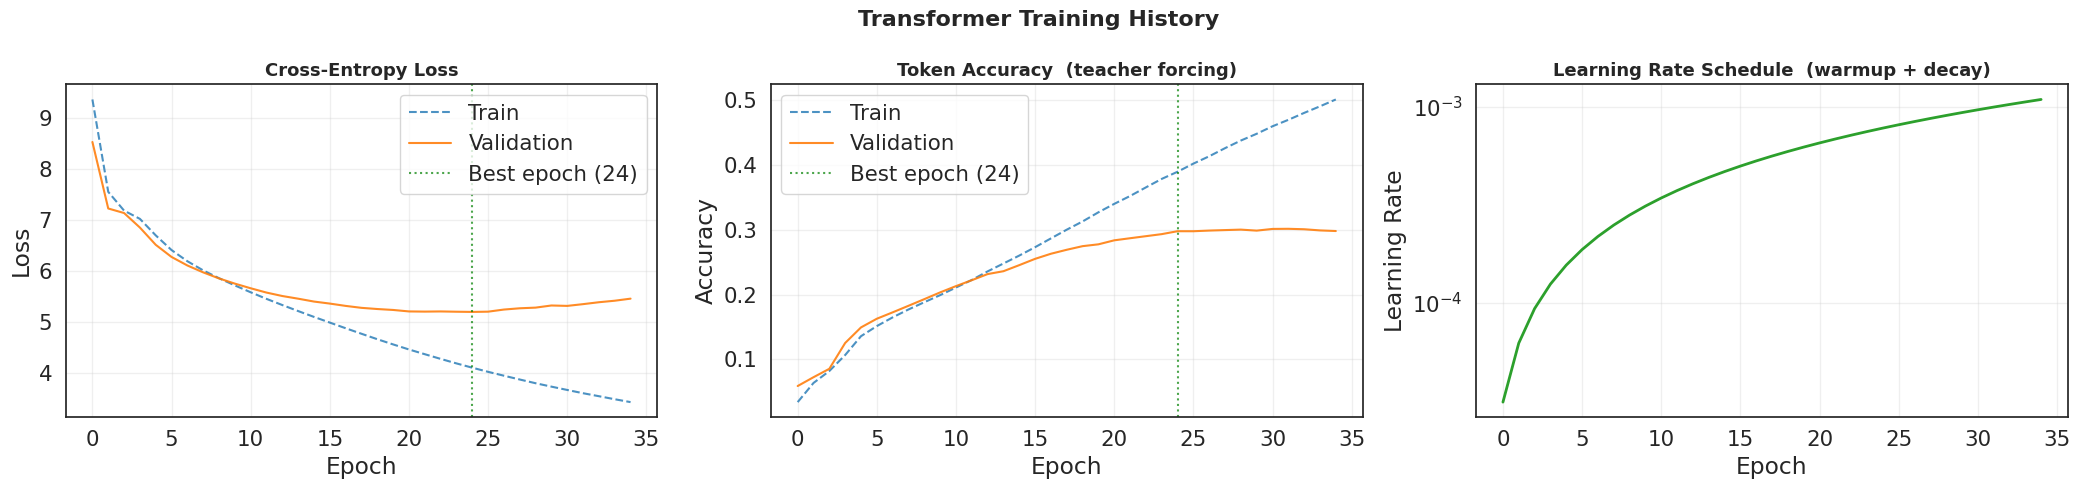

In [25]:
# Identify epoch with lowest validation loss
best_epoch = int(np.argmin(history['val_loss']))

fig, axes = plt.subplots(1, 3, figsize=(21, 5))
fig.suptitle('Transformer Training History', fontsize=16, fontweight='bold')

# ── Cross-Entropy Loss ─────────────────────────────────────────────────────
axes[0].plot(history['train_loss'], color='#1f77b4', linestyle='--', alpha=0.8, label='Train')
axes[0].plot(history['val_loss'],   color='#ff7f0e', linestyle='-',  alpha=0.9, label='Validation')
axes[0].axvline(best_epoch, color='green', linestyle=':', alpha=0.7,
                label=f'Best epoch ({best_epoch})')
axes[0].set_title('Cross-Entropy Loss', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(alpha=0.3)

# ── Token Accuracy (teacher forcing) ──────────────────────────────────────
axes[1].plot(history['train_acc'], color='#1f77b4', linestyle='--', alpha=0.8, label='Train')
axes[1].plot(history['val_acc'],   color='#ff7f0e', linestyle='-',  alpha=0.9, label='Validation')
axes[1].axvline(best_epoch, color='green', linestyle=':', alpha=0.7,
                label=f'Best epoch ({best_epoch})')
axes[1].set_title('Token Accuracy  (teacher forcing)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(alpha=0.3)

# ── Learning Rate Schedule ─────────────────────────────────────────────────
axes[2].plot(history['lr'], color='#2ca02c', linewidth=2)
axes[2].set_title('Learning Rate Schedule  (warmup + decay)', fontsize=13, fontweight='bold')
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('Learning Rate')
axes[2].set_yscale('log')
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [26]:
# Evaluate token accuracy on the test set (teacher forcing, same metric as training)
test_loss, test_acc = validate_one_epoch(model, test_loader, criterion, device)
print(f"Test set evaluation:\n"
      f"  Loss:           {test_loss:.4f}\n"
      f"  Token Accuracy: {test_acc:.4f}")

Test set evaluation:
  Loss:           5.2134
  Token Accuracy: 0.2938


## **Embedding Space Analysis**

After training, the model's embedding matrices encode semantic structure:
words used in similar contexts end up close in vector space. The two
visualisations below probe this structure directly — no task-specific
information, just the raw geometry of the learned representations.

In [27]:
# Helper: retrieve the embedding vector for a word-initial BPE piece (▁word)
def _get_piece_embedding(sp: spm.SentencePieceProcessor,
                         emb_matrix: np.ndarray, word: str) -> Optional[np.ndarray]:
    """Return embedding vector for '▁word', or None if the piece maps to UNK."""
    piece_id = sp.piece_to_id(f'▁{word}')
    if piece_id == UNK_IDX:
        return None
    return emb_matrix[piece_id]


def plot_nearest_neighbours(model: nn.Module, sp: spm.SentencePieceProcessor,
                            query_words: list[str], k: int = 8,
                            lang: str = 'src') -> None:
    """
    Display top-k nearest neighbours by cosine similarity for each query word.

    Args:
        model:       Trained Seq2SeqTransformer
        sp:          Shared BPE SentencePieceProcessor
        query_words: List of lowercase words to query
        k:           Number of neighbours to show per word
        lang:        'src' or 'tgt' embedding matrix to use
    """
    emb_layer  = model.src_embedding if lang == 'src' else model.tgt_embedding
    emb_matrix = emb_layer.weight.detach().cpu().numpy()

    # Normalise all embeddings once for efficient cosine similarity
    norms      = np.linalg.norm(emb_matrix, axis=1, keepdims=True)
    emb_normed = emb_matrix / (norms + 1e-9)

    valid = [(w, _get_piece_embedding(sp, emb_matrix, w)) for w in query_words]
    valid = [(w, v) for w, v in valid if v is not None]

    if not valid:
        print("None of the query words found as BPE pieces.")
        return

    n_queries = len(valid)
    fig, axes = plt.subplots(1, n_queries,
                             figsize=(4 * n_queries, max(4, k * 0.55)))
    if n_queries == 1:
        axes = [axes]

    lang_label = 'Source' if lang == 'src' else 'Target'
    fig.suptitle(
        f'Top-{k} Nearest Neighbours in {lang_label} Embedding Space\n'
        f'Cosine similarity — higher = more similar',
        fontsize=14, fontweight='bold'
    )

    for ax, (word, vec) in zip(axes, valid):
        query_normed = vec / (np.linalg.norm(vec) + 1e-9)
        sims = emb_normed @ query_normed

        # Top-k excluding the query word itself
        query_id  = sp.piece_to_id(f'▁{word}')
        sims[query_id] = -1.0
        top_idxs  = np.argsort(sims)[::-1][:k]
        top_words = [sp.id_to_piece(int(i)).replace('▁', '') for i in top_idxs]
        top_sims  = sims[top_idxs]

        colors = plt.cm.YlOrRd(
            (top_sims - top_sims.min()) / (top_sims.max() - top_sims.min() + 1e-9)
        )
        bars = ax.barh(range(k), top_sims, color=colors, alpha=0.85)
        ax.set_yticks(range(k))
        ax.set_yticklabels(top_words, fontsize=10)
        ax.invert_yaxis()
        ax.set_title(f'"{word}"', fontsize=13, fontweight='bold')
        ax.set_xlabel('Cosine similarity', fontsize=10)
        ax.set_xlim(0, 1.05)
        ax.bar_label(bars, labels=[f'{s:.2f}' for s in top_sims],
                     padding=3, fontsize=8)
        ax.grid(alpha=0.3, axis='x')

    plt.tight_layout()
    plt.show()


def plot_similarity_heatmap(model: nn.Module, sp: spm.SentencePieceProcessor,
                            word_groups: dict[str, list[str]],
                            lang: str = 'src') -> None:
    """
    Plot a lower-triangular cosine similarity heatmap for curated semantic word groups.

    Words are arranged by group with group boundaries highlighted. Within-group
    similarity should be higher than between-group for well-trained embeddings.
    The upper triangle is masked to avoid redundancy.

    Args:
        model:       Trained Seq2SeqTransformer
        sp:          Shared BPE SentencePieceProcessor
        word_groups: Dict mapping group name → list of words
        lang:        'src' or 'tgt' embedding matrix to use
    """
    emb_layer  = model.src_embedding if lang == 'src' else model.tgt_embedding
    emb_matrix = emb_layer.weight.detach().cpu().numpy()

    words, vectors, group_sizes = [], [], []

    for group_name, word_list in word_groups.items():
        found = 0
        for word in word_list:
            vec = _get_piece_embedding(sp, emb_matrix, word)
            if vec is not None:
                words.append(word)
                vectors.append(vec)
                found += 1
        group_sizes.append(found)

    if len(words) < 2:
        print("Not enough words found in vocabulary.")
        return

    vectors = np.array(vectors)
    norms   = np.linalg.norm(vectors, axis=1, keepdims=True)
    normed  = vectors / (norms + 1e-9)
    sim_mat = normed @ normed.T

    # Mask upper triangle (keep diagonal and lower triangle only)
    mask = np.triu(np.ones_like(sim_mat, dtype=bool), k=1)

    n = len(words)
    fig, ax = plt.subplots(figsize=(max(7, n * 0.6), max(6, n * 0.5)))
    lang_label = 'Source' if lang == 'src' else 'Target'

    sns.heatmap(sim_mat, ax=ax,
                mask=mask,
                annot=True, fmt='.2f', annot_kws={'size': 8},
                cmap='RdYlGn', vmin=-0.5, vmax=1.0, center=0,
                xticklabels=words, yticklabels=words,
                linewidths=0.4, linecolor='white',
                cbar_kws={'label': 'Cosine Similarity', 'shrink': 0.8})

    # Draw group boundary lines
    boundary = 0
    for size in group_sizes[:-1]:
        boundary += size
        ax.axhline(boundary, color='black', linewidth=1.0)
        ax.axvline(boundary, color='black', linewidth=1.0)

    # Group name annotations — placed with enough left margin to avoid overlap
    boundary = 0
    for (group_name, _), size in zip(word_groups.items(), group_sizes):
        mid = boundary + size / 2
        ax.text(-2.00, mid, group_name, fontsize=10, fontweight='bold',
                ha='right', va='center', rotation=0)
        boundary += size

    ax.set_title(
        f'Embedding Cosine Similarity  —  {lang_label}\n'
        f'Diagonal blocks = within-group  |  Off-diagonal = cross-group',
        fontsize=13, fontweight='bold'
    )
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=9)
    ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=9)
    plt.tight_layout()
    plt.show()

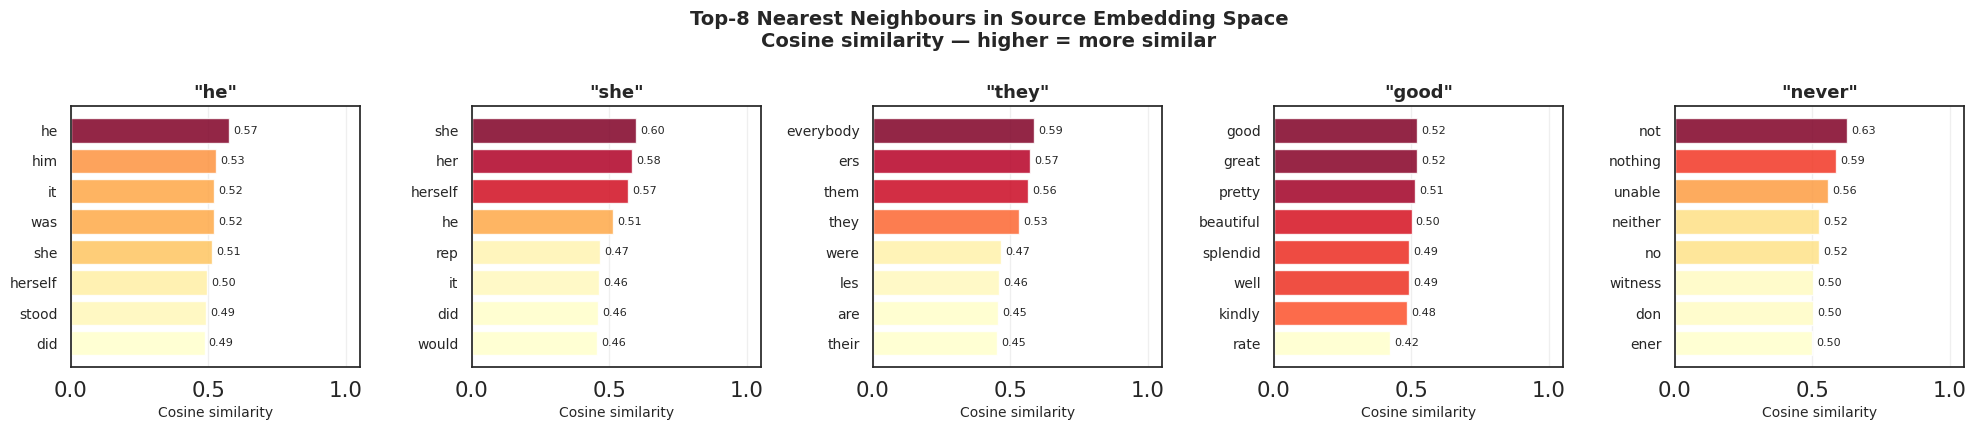

In [28]:
# Pronouns and common function words cluster by grammatical role, not meaning
plot_nearest_neighbours(
    model, sp,
    query_words=['he', 'she', 'they', 'good', 'never'],
    k=8, lang='src'
)

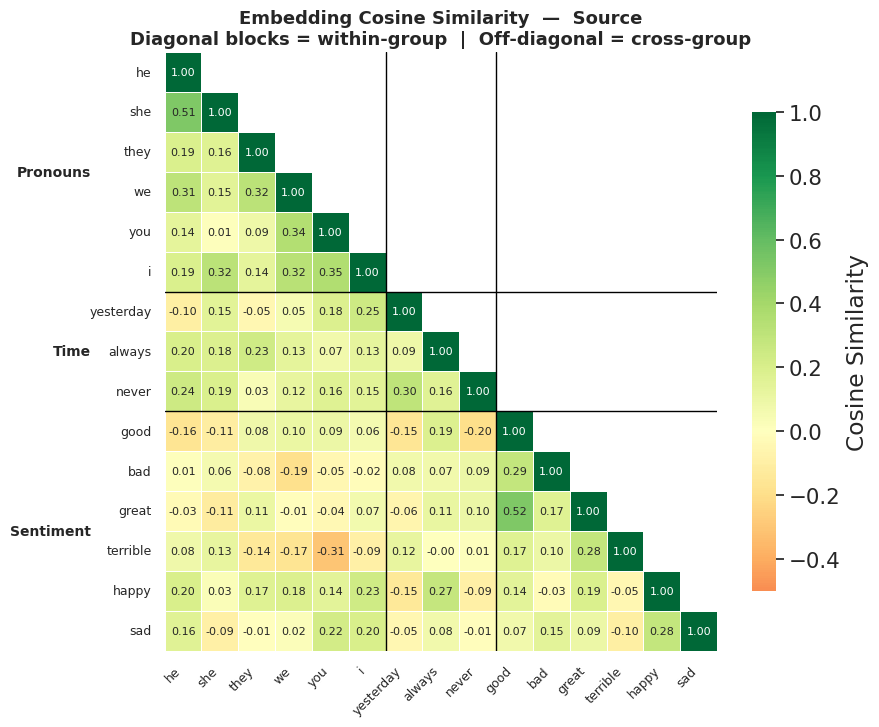

In [29]:
WORD_GROUPS = {
    'Pronouns':  ['he', 'she', 'they', 'we', 'you', 'i'],
    'Time':      ['today', 'yesterday', 'tomorrow', 'always', 'never'],
    'Sentiment': ['good', 'bad', 'great', 'terrible', 'happy', 'sad'],
}
plot_similarity_heatmap(model, sp, WORD_GROUPS, lang='src')

## **Attention Visualisation**

The Transformer's key innovation is that its attention weights are the model's
internal reasoning made directly visible. The three visualisations below
build a narrative in three acts:

**Act 1 — How the encoder understands source text**
Encoder self-attention shows how each English word contextualises itself by
attending to other words in the sentence. Syntactic patterns emerge here:
verbs attending to subjects, pronouns to their antecedents.

**Act 2 — How the decoder aligns to the source**
Cross-attention is the alignment matrix: rows are Italian tokens being generated,
columns are English source tokens. A near-diagonal pattern means the translation
is largely monotonic; off-diagonal clusters reveal reorderings. This is the most
pedagogically important visualisation — it makes the translation process legible.

**Act 3 — Specialisation across heads**
Viewing all heads side by side shows that different heads learn different
linguistic relationships. Some specialise in syntactic dependencies, others in
semantic similarity, others in positional proximity.

> **Note — Attention Sinks**
> In short sentences it is common for one token (often the final punctuation)
> to accumulate disproportionately high attention across multiple heads. This is
> not a bug: the softmax must sum to 1, so residual weight is dumped onto a
> structurally neutral position. This phenomenon is known as the *attention sink*
> effect and is observed in models of all sizes.

In [30]:
def _piece_label(sp: spm.SentencePieceProcessor, token_id: int) -> str:
    """
    Return a display-safe axis label for any BPE token ID.

    Wraps single punctuation characters in angle-brackets so they are
    visually distinct at small font sizes (e.g. '.' → '<.>').

    Args:
        sp:       Trained SentencePieceProcessor
        token_id: Integer BPE token ID to convert

    Returns:
        Non-empty string suitable for a matplotlib tick label
    """
    _SPECIAL = {PAD_IDX: '<pad>', BOS_IDX: '<bos>',
                EOS_IDX: '<eos>', UNK_IDX: '<unk>'}
    if token_id in _SPECIAL:
        return _SPECIAL[token_id]

    piece = sp.id_to_piece(token_id)
    clean = piece.replace('▁', '').strip()

    if not clean:
        return f'[{token_id}]'

    # Single punctuation becomes nearly invisible at fontsize=9 — wrap it
    if len(clean) == 1 and not clean.isalnum():
        return f'<{clean}>'

    return piece


def _run_forward(model: nn.Module, eng: str,
                 device: torch.device) -> tuple[list[str], list[str]]:
    """
    Translate one English sentence with greedy decoding and populate all
    attention weight caches in the process.

    Autoregressive inference is used (not teacher forcing) so cross-attention
    weights reflect the real generation process. The generated sequence is
    then passed through the decoder in one shot to populate all layer caches
    with a consistent sequence length, guaranteeing label/matrix alignment.

    Args:
        model:  Trained Seq2SeqTransformer
        eng:    English source sentence
        device: Computation device

    Returns:
        (src_tokens, tgt_tokens) as display-safe BPE piece strings.
        src_tokens: every non-PAD source position.
        tgt_tokens: BOS + every generated token up to EOS (exclusive).
    """
    model.eval()

    src_enc = encode_bpe(sp, eng, SEQ_LEN_SRC)
    src_ids = torch.tensor(src_enc, dtype=torch.long).unsqueeze(0).to(device)
    src_pad_mask = (src_ids == PAD_IDX)

    # First PAD position marks the content/padding boundary
    n_src      = next((i for i, v in enumerate(src_enc) if v == PAD_IDX), len(src_enc))
    src_tokens = [_piece_label(sp, src_enc[i]) for i in range(n_src)]

    with torch.no_grad():
        memory = model.encode(src_ids, src_key_padding_mask=src_pad_mask)

    # Greedy decode step-by-step
    generated = [BOS_IDX]
    for _ in range(SEQ_LEN_TGT + 5):
        tgt_step = torch.tensor(generated, dtype=torch.long).unsqueeze(0).to(device)
        tgt_mask = nn.Transformer.generate_square_subsequent_mask(
            tgt_step.size(1), device=device
        )
        with torch.no_grad():
            decoded = model.decode(tgt_step, memory,
                                   tgt_mask=tgt_mask,
                                   memory_key_padding_mask=src_pad_mask)
            logits = model.output_projection(decoded)

        next_token = logits[0, -1, :].argmax().item()
        generated.append(next_token)
        if next_token == EOS_IDX:
            break

    # [BOS, tok1, ..., tokN, EOS] → keep everything except EOS
    tgt_display = [t for t in generated if t != EOS_IDX]
    tgt_tokens  = [_piece_label(sp, t) for t in tgt_display]

    # Final full-sequence decoder pass to populate all layer caches consistently.
    # Shape: (1, heads, len(tgt_display), SEQ_LEN_SRC) — exactly matches tgt_tokens.
    tgt_full = torch.tensor(tgt_display, dtype=torch.long).unsqueeze(0).to(device)
    tgt_mask_full = nn.Transformer.generate_square_subsequent_mask(
        tgt_full.size(1), device=device
    )
    with torch.no_grad():
        _ = model.decode(tgt_full, memory,
                         tgt_mask=tgt_mask_full,
                         memory_key_padding_mask=src_pad_mask)

    return src_tokens, tgt_tokens


# Run on one fixed test example — reused across all attention plots
EXAMPLE_IDX = 0
ex_eng, ex_ita = test_pairs[EXAMPLE_IDX]
print(f"Attention example:\n  EN: {ex_eng}\n  IT: {ex_ita}\n")
src_toks, tgt_toks = _run_forward(model, ex_eng, device)

Attention example:
  EN: He was in the position of a man seeking for food in a toyshop or at a gunsmith's.
  IT: Era nella situazione di un uomo che cerca il cibo in una bottega di giocattoli o di armi.



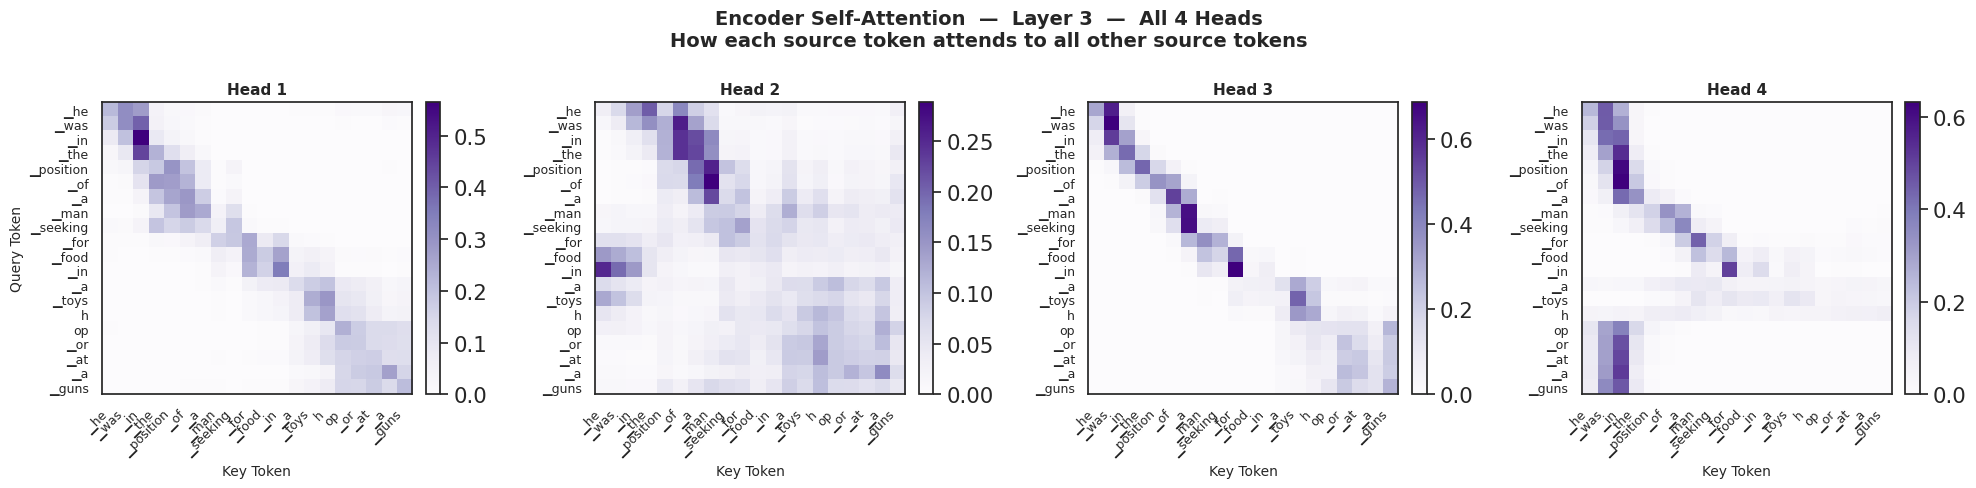

In [45]:
def plot_encoder_self_attention(model: nn.Module, src_tokens: list[str],
                                layer_idx: int = -1) -> None:
    """
    Plot encoder self-attention for all heads in a given layer.

    Args:
        model:      Trained Seq2SeqTransformer (run _run_forward first)
        src_tokens: Source token strings (axis labels)
        layer_idx:  Which encoder layer to visualise (0 = first, -1 = last)
    """
    block = model.encoder_blocks[layer_idx]
    if block.last_attn_weights is None:
        print("No weights cached — call _run_forward() first.")
        return

    n_src     = len(src_tokens)
    attn      = block.last_attn_weights[0, :, :n_src, :n_src].cpu().numpy()
    num_heads = attn.shape[0]

    # Resolve negative index for display
    display_layer = layer_idx % len(model.encoder_blocks) + 1

    fig, axes = plt.subplots(1, num_heads, figsize=(5 * num_heads, 5))
    fig.suptitle(
        f'Encoder Self-Attention  —  Layer {display_layer}  —  All {num_heads} Heads\n'
        f'How each source token attends to all other source tokens',
        fontsize=14, fontweight='bold'
    )
    for h, ax in enumerate(axes):
        im = ax.imshow(attn[h], aspect='auto', cmap='Purples',
                       vmin=0, vmax=attn[h].max() + 1e-9)
        ax.set_xticks(range(n_src))
        ax.set_xticklabels(src_tokens, rotation=45, ha='right', fontsize=9)
        ax.set_yticks(range(n_src))
        ax.set_yticklabels(src_tokens, fontsize=9)
        ax.set_title(f'Head {h + 1}', fontsize=11, fontweight='bold')
        ax.set_xlabel('Key Token', fontsize=10)
        if h == 0:
            ax.set_ylabel('Query Token', fontsize=10)
        plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

    plt.tight_layout()
    plt.show()


plot_encoder_self_attention(model, src_toks, layer_idx=-1)

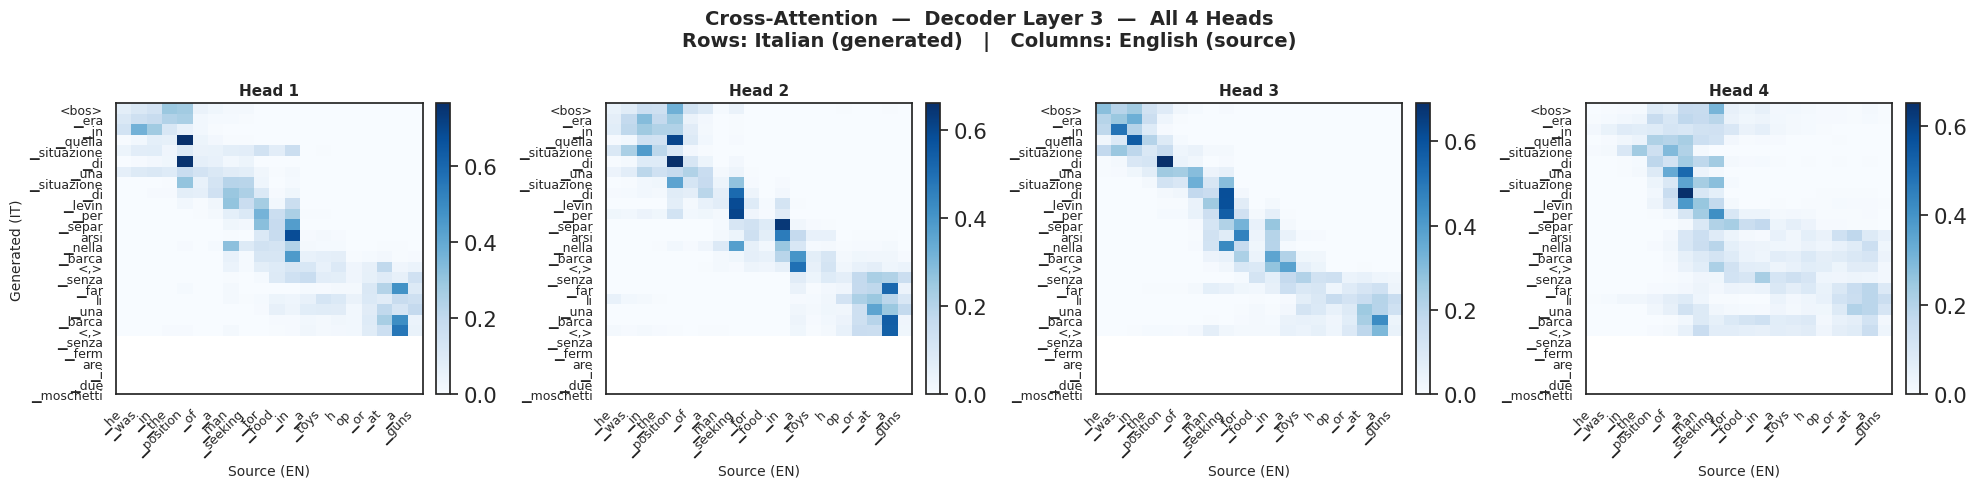

In [46]:
def plot_cross_attention_heads(model: nn.Module, src_tokens: list[str],
                               tgt_tokens: list[str], layer_idx: int = -1) -> None:
    """
    Plot cross-attention for all heads in one decoder layer.

    Rows = Italian tokens generated; columns = English source tokens.
    Diagonal = monotonic alignment; off-diagonal = structural reordering.

    Args:
        model:      Trained Seq2SeqTransformer (run _run_forward first)
        src_tokens: Source token strings (x-axis)
        tgt_tokens: Target token strings (y-axis)
        layer_idx:  Decoder layer to visualise (-1 = last)
    """
    block = model.decoder_blocks[layer_idx]
    if block.last_cross_attn_weights is None:
        print("No weights cached — call _run_forward() first.")
        return

    n_src, n_tgt = len(src_tokens), len(tgt_tokens)
    attn          = block.last_cross_attn_weights[0, :, :n_tgt, :n_src].cpu().numpy()
    num_heads     = attn.shape[0]

    display_layer = layer_idx % len(model.decoder_blocks) + 1

    fig, axes = plt.subplots(1, num_heads, figsize=(5 * num_heads, 5))
    fig.suptitle(
        f'Cross-Attention  —  Decoder Layer {display_layer}  —  All {num_heads} Heads\n'
        f'Rows: Italian (generated)   |   Columns: English (source)',
        fontsize=14, fontweight='bold'
    )
    for h, ax in enumerate(axes):
        im = ax.imshow(attn[h], aspect='auto', cmap='Blues',
                       vmin=0, vmax=attn[h].max() + 1e-9)
        ax.set_xticks(range(n_src))
        ax.set_xticklabels(src_tokens, rotation=45, ha='right', fontsize=9)
        ax.set_yticks(range(n_tgt))
        ax.set_yticklabels(tgt_tokens, fontsize=9)
        ax.set_title(f'Head {h + 1}', fontsize=11, fontweight='bold')
        ax.set_xlabel('Source (EN)', fontsize=10)
        if h == 0:
            ax.set_ylabel('Generated (IT)', fontsize=10)
        plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

    plt.tight_layout()
    plt.show()


plot_cross_attention_heads(model, src_toks, tgt_toks, layer_idx=-1)

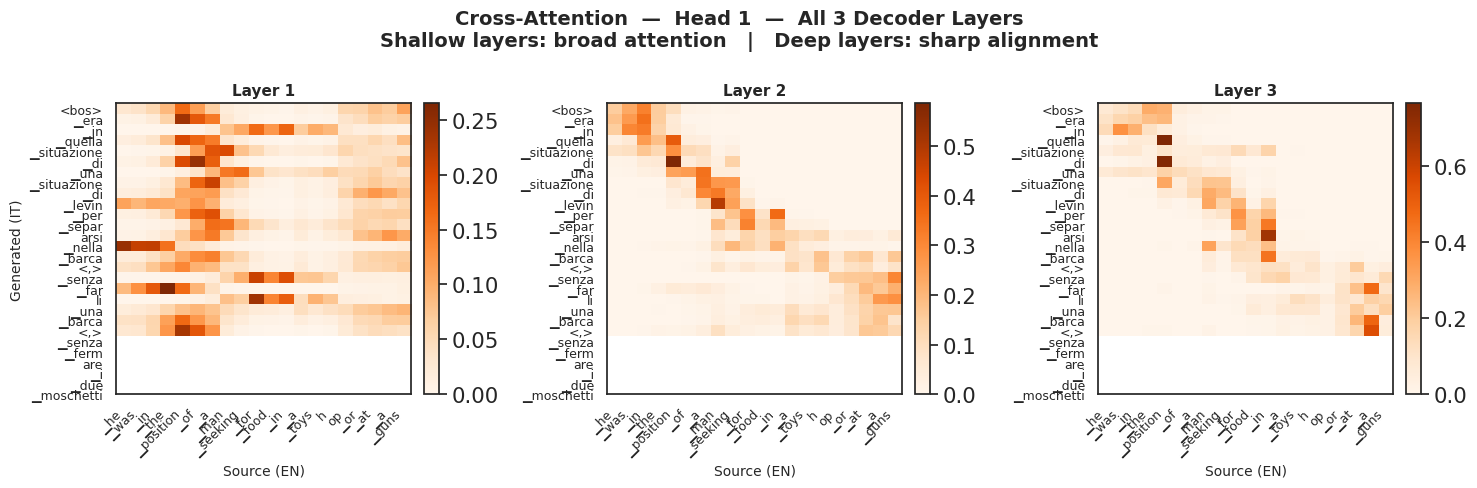

In [47]:
def plot_cross_attention_layers(model: nn.Module, src_tokens: list[str],
                                tgt_tokens: list[str], head_idx: int = 0) -> None:
    """
    Plot cross-attention for a single head across every decoder layer.

    Shallow layers tend to have broad, diffuse attention; deeper layers
    sharpen into precise token-to-token alignments.

    Args:
        model:      Trained Seq2SeqTransformer (run _run_forward first)
        src_tokens: Source token strings
        tgt_tokens: Target token strings
        head_idx:   Which attention head to display
    """
    n_src, n_tgt = len(src_tokens), len(tgt_tokens)
    num_layers   = len(model.decoder_blocks)

    fig, axes = plt.subplots(1, num_layers, figsize=(5 * num_layers, 5))
    fig.suptitle(
        f'Cross-Attention  —  Head {head_idx + 1}  —  All {num_layers} Decoder Layers\n'
        f'Shallow layers: broad attention   |   Deep layers: sharp alignment',
        fontsize=14, fontweight='bold'
    )
    for l_idx, (block, ax) in enumerate(zip(model.decoder_blocks, axes)):
        if block.last_cross_attn_weights is None:
            continue
        attn = block.last_cross_attn_weights[0, head_idx, :n_tgt, :n_src].cpu().numpy()
        im   = ax.imshow(attn, aspect='auto', cmap='Oranges',
                         vmin=0, vmax=attn.max() + 1e-9)
        ax.set_xticks(range(n_src))
        ax.set_xticklabels(src_tokens, rotation=45, ha='right', fontsize=9)
        ax.set_yticks(range(n_tgt))
        ax.set_yticklabels(tgt_tokens, fontsize=9)
        ax.set_title(f'Layer {l_idx + 1}', fontsize=11, fontweight='bold')
        ax.set_xlabel('Source (EN)', fontsize=10)
        if l_idx == 0:
            ax.set_ylabel('Generated (IT)', fontsize=10)
        plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

    plt.tight_layout()
    plt.show()


plot_cross_attention_layers(model, src_toks, tgt_toks, head_idx=0)

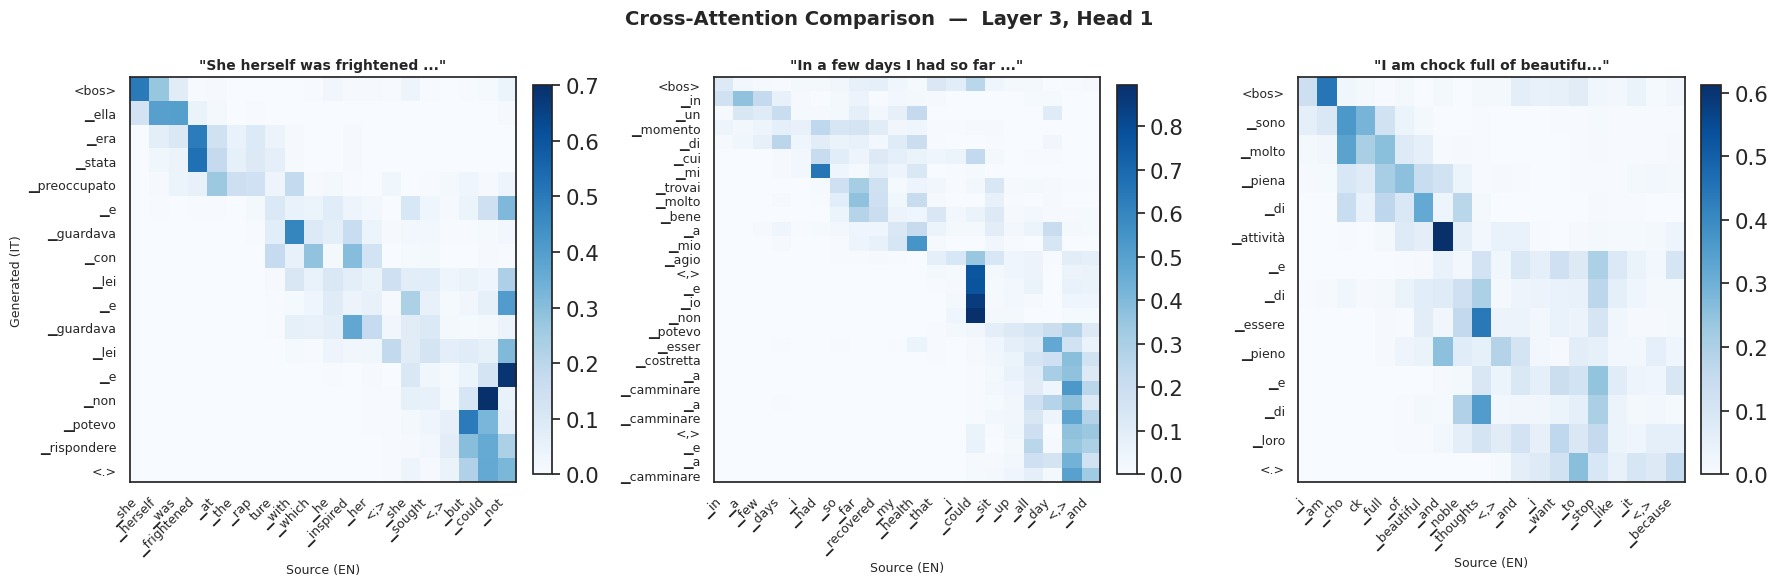

In [48]:
def compare_cross_attention(model: nn.Module,
                             sentences: list[str],
                             device: torch.device,
                             layer_idx: int = -1,
                             head_idx: int = 0) -> None:
    """
    Compare cross-attention alignment across multiple source sentences.

    Viewing several pairs side by side reveals how alignment changes with
    sentence length, word order, and morphological complexity.

    Args:
        model:      Trained Seq2SeqTransformer
        sentences:  List of English source strings to translate and visualise
        device:     Computation device
        layer_idx:  Decoder layer to visualise
        head_idx:   Attention head to display
    """
    n = len(sentences)
    fig, axes = plt.subplots(1, n, figsize=(6 * n, 6))
    if n == 1:
        axes = [axes]

    display_layer = layer_idx % len(model.decoder_blocks) + 1
    fig.suptitle(
        f'Cross-Attention Comparison  —  Layer {display_layer}, Head {head_idx + 1}',
        fontsize=14, fontweight='bold'
    )
    for ax, eng in zip(axes, sentences):
        src_tok, tgt_tok = _run_forward(model, eng, device)
        block  = model.decoder_blocks[layer_idx]
        n_s, n_t = len(src_tok), len(tgt_tok)
        attn = block.last_cross_attn_weights[0, head_idx, :n_t, :n_s].cpu().numpy()

        im = ax.imshow(attn, aspect='auto', cmap='Blues',
                       vmin=0, vmax=attn.max() + 1e-9)
        ax.set_xticks(range(n_s))
        ax.set_xticklabels(src_tok, rotation=45, ha='right', fontsize=9)
        ax.set_yticks(range(n_t))
        ax.set_yticklabels(tgt_tok, fontsize=9)
        title = f'"{eng}"' if len(eng) <= 30 else f'"{eng[:27]}..."'
        ax.set_title(title, fontsize=10, fontweight='bold')
        ax.set_xlabel('Source (EN)', fontsize=9)
        if ax is axes[0]:
            ax.set_ylabel('Generated (IT)', fontsize=9)
        plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

    plt.tight_layout()
    plt.show()


compare_cross_attention(model, [eng for eng, _ in random.sample(test_pairs, 3)],
                        device, layer_idx=-1, head_idx=0)

## **Inference**

In [41]:
def greedy_decode(model: nn.Module, src_sentence: str,
                  sp: spm.SentencePieceProcessor,
                  src_seq_len: int, max_steps: int,
                  device: torch.device) -> str:
    """
    Translate a single English sentence using greedy (argmax) decoding.

    Encodes the source once, then autoregressively generates tokens one at
    a time until EOS is produced or max_steps is reached.

    Args:
        model:        Trained Seq2SeqTransformer
        src_sentence: Raw English input string
        sp:           Shared BPE SentencePieceProcessor
        src_seq_len:  Maximum source sequence length
        max_steps:    Maximum tokens to generate
        device:       Computation device

    Returns:
        Translated Italian sentence as a string (special tokens removed)
    """
    model.eval()

    src_ids = torch.tensor(
        encode_bpe(sp, src_sentence, src_seq_len), dtype=torch.long
    ).unsqueeze(0).to(device)

    src_pad_mask = (src_ids == PAD_IDX)
    with torch.no_grad():
        memory = model.encode(src_ids, src_key_padding_mask=src_pad_mask)

    generated = [BOS_IDX]

    for _ in range(max_steps):
        tgt_ids  = torch.tensor(generated, dtype=torch.long).unsqueeze(0).to(device)
        tgt_mask = nn.Transformer.generate_square_subsequent_mask(
            tgt_ids.size(1), device=device
        )
        with torch.no_grad():
            decoded = model.decode(tgt_ids, memory, tgt_mask=tgt_mask,
                                   memory_key_padding_mask=src_pad_mask)
            logits  = model.output_projection(decoded)

        next_token = logits[0, -1, :].argmax().item()
        generated.append(next_token)
        if next_token == EOS_IDX:
            break

    return decode_bpe(sp, generated)


# Print sample translations with reference for qualitative inspection
print("Sample translations from test set:\n")
for eng, ref_ita in random.sample(test_pairs, 10):
    translation = greedy_decode(model, eng, sp, SEQ_LEN_SRC, SEQ_LEN_TGT + 5, device)
    print(f"  EN:  {eng}\n  REF: {ref_ita}\n  HYP: {translation}\n")

Sample translations from test set:

  EN:  'Positively and finally' were the dealer's favourite words.
  REF: «Definitivamente e positivamente» erano gli intercalari del compratore.
  HYP: —  ⁇ poschepe e il suo desinare.

  EN:  At last the guilty Kuzma, quite out of breath, rushed in with the shirt.
  REF: Alla fine Kuz’ma, il colpevole, respirando a stento, irruppe nella stanza con la camicia.
  HYP: finalmente, levin, konstantin levin, tirava fuori fuori fuori dalla camicia, con la camicia.

  EN:  A servant in waiting took my horse, and I entered the Gothic archway of the hall.
  REF: Un servo prese il mio cavallo ed io entrai sotto la volta gotica del vestibolo.
  HYP: la carrozza si aspettava la mia lettera e mi misi a leggere la signora fairfax.

  EN:  Two days are passed.
  REF: Sono passati due giorni.
  HYP: due giorni sono.

  EN:  But the words had been spoken and Karenin had gone away without saying anything.
  REF: Ma le parole erano state dette, e Aleksej Aleksandrovic

In [36]:
def beam_decode(
    model: nn.Module,
    src_sentence: str,
    sp: spm.SentencePieceProcessor,
    src_seq_len: int,
    max_steps: int,
    device: torch.device,
    beam_size: int = 4,
    length_penalty: float = 0.6,
) -> str:
    """
    Translate a single English sentence using beam search decoding.

    Keeps `beam_size` partial hypotheses alive at every step, selects the
    next top-k tokens across all beams, and finalises hypotheses that emit
    EOS.  Final score is length-normalised to prevent the model from
    favouring short outputs:

        score = cumulative_log_prob / (hypothesis_length ** length_penalty)

    Args:
        model:          Trained Seq2SeqTransformer.
        src_sentence:   Raw English input string.
        sp:             Shared BPE SentencePieceProcessor.
        src_seq_len:    Maximum source sequence length (for padding/truncation).
        max_steps:      Maximum number of decoding steps.
        device:         Computation device.
        beam_size:      Number of beams (1 degenerates to greedy argmax).
        length_penalty: Exponent α in the normalisation denominator
                        (0 = no normalisation, 0.6–1.0 typical range).

    Returns:
        Translated Italian sentence as a plain string (special tokens removed).
    """
    model.eval()

    # ── Encode source once ────────────────────────────────────────────────────
    src_ids = torch.tensor(
        encode_bpe(sp, src_sentence, src_seq_len), dtype=torch.long
    ).unsqueeze(0).to(device)                        # (1, S)

    src_pad_mask = (src_ids == PAD_IDX)              # (1, S)
    with torch.no_grad():
        memory = model.encode(src_ids, src_key_padding_mask=src_pad_mask)

    # ── Beam state: list of (cumulative_log_prob, token_ids) ─────────────────
    beams: list[tuple[float, list[int]]] = [(0.0, [BOS_IDX])]
    completed: list[tuple[float, list[int]]] = []

    for _ in range(max_steps):
        if not beams:
            break

        # Build batched decoder input from all active beams
        tgt_batch = torch.tensor(
            [b[1] for b in beams], dtype=torch.long
        ).to(device)                                 # (num_beams, t)

        seq_len  = tgt_batch.size(1)
        num_beams = tgt_batch.size(0)
        tgt_mask  = nn.Transformer.generate_square_subsequent_mask(
            seq_len, device=device
        )

        # Expand encoder outputs to match the number of live beams
        mem_exp      = memory.expand(num_beams, -1, -1)      # (B, S, d)
        src_mask_exp = src_pad_mask.expand(num_beams, -1)    # (B, S)

        with torch.no_grad():
            decoded = model.decode(
                tgt_batch, mem_exp,
                tgt_mask=tgt_mask,
                memory_key_padding_mask=src_mask_exp,
            )
            logits = model.output_projection(decoded)        # (B, t, V)

        # Only need the last-position logits
        log_probs = torch.log_softmax(logits[:, -1, :], dim=-1)  # (B, V)

        # Collect top-k candidates from every beam
        all_candidates: list[tuple[float, list[int]]] = []
        for i, (score, tokens) in enumerate(beams):
            top_log_probs, top_ids = log_probs[i].topk(beam_size)
            for log_p, tok_id in zip(top_log_probs.tolist(), top_ids.tolist()):
                new_score  = score + log_p
                new_tokens = tokens + [tok_id]
                if tok_id == EOS_IDX:
                    norm = len(new_tokens) ** length_penalty
                    completed.append((new_score / norm, new_tokens))
                else:
                    all_candidates.append((new_score, new_tokens))

        # Prune to the best `beam_size` active beams
        all_candidates.sort(key=lambda x: x[0], reverse=True)
        beams = all_candidates[:beam_size]

    # Fallback: if nothing ever hit EOS, promote the best active beam
    if not completed:
        best_score, best_tokens = beams[0]
        norm = len(best_tokens) ** length_penalty
        completed = [(best_score / norm, best_tokens)]

    completed.sort(key=lambda x: x[0], reverse=True)
    return decode_bpe(sp, completed[0][1])


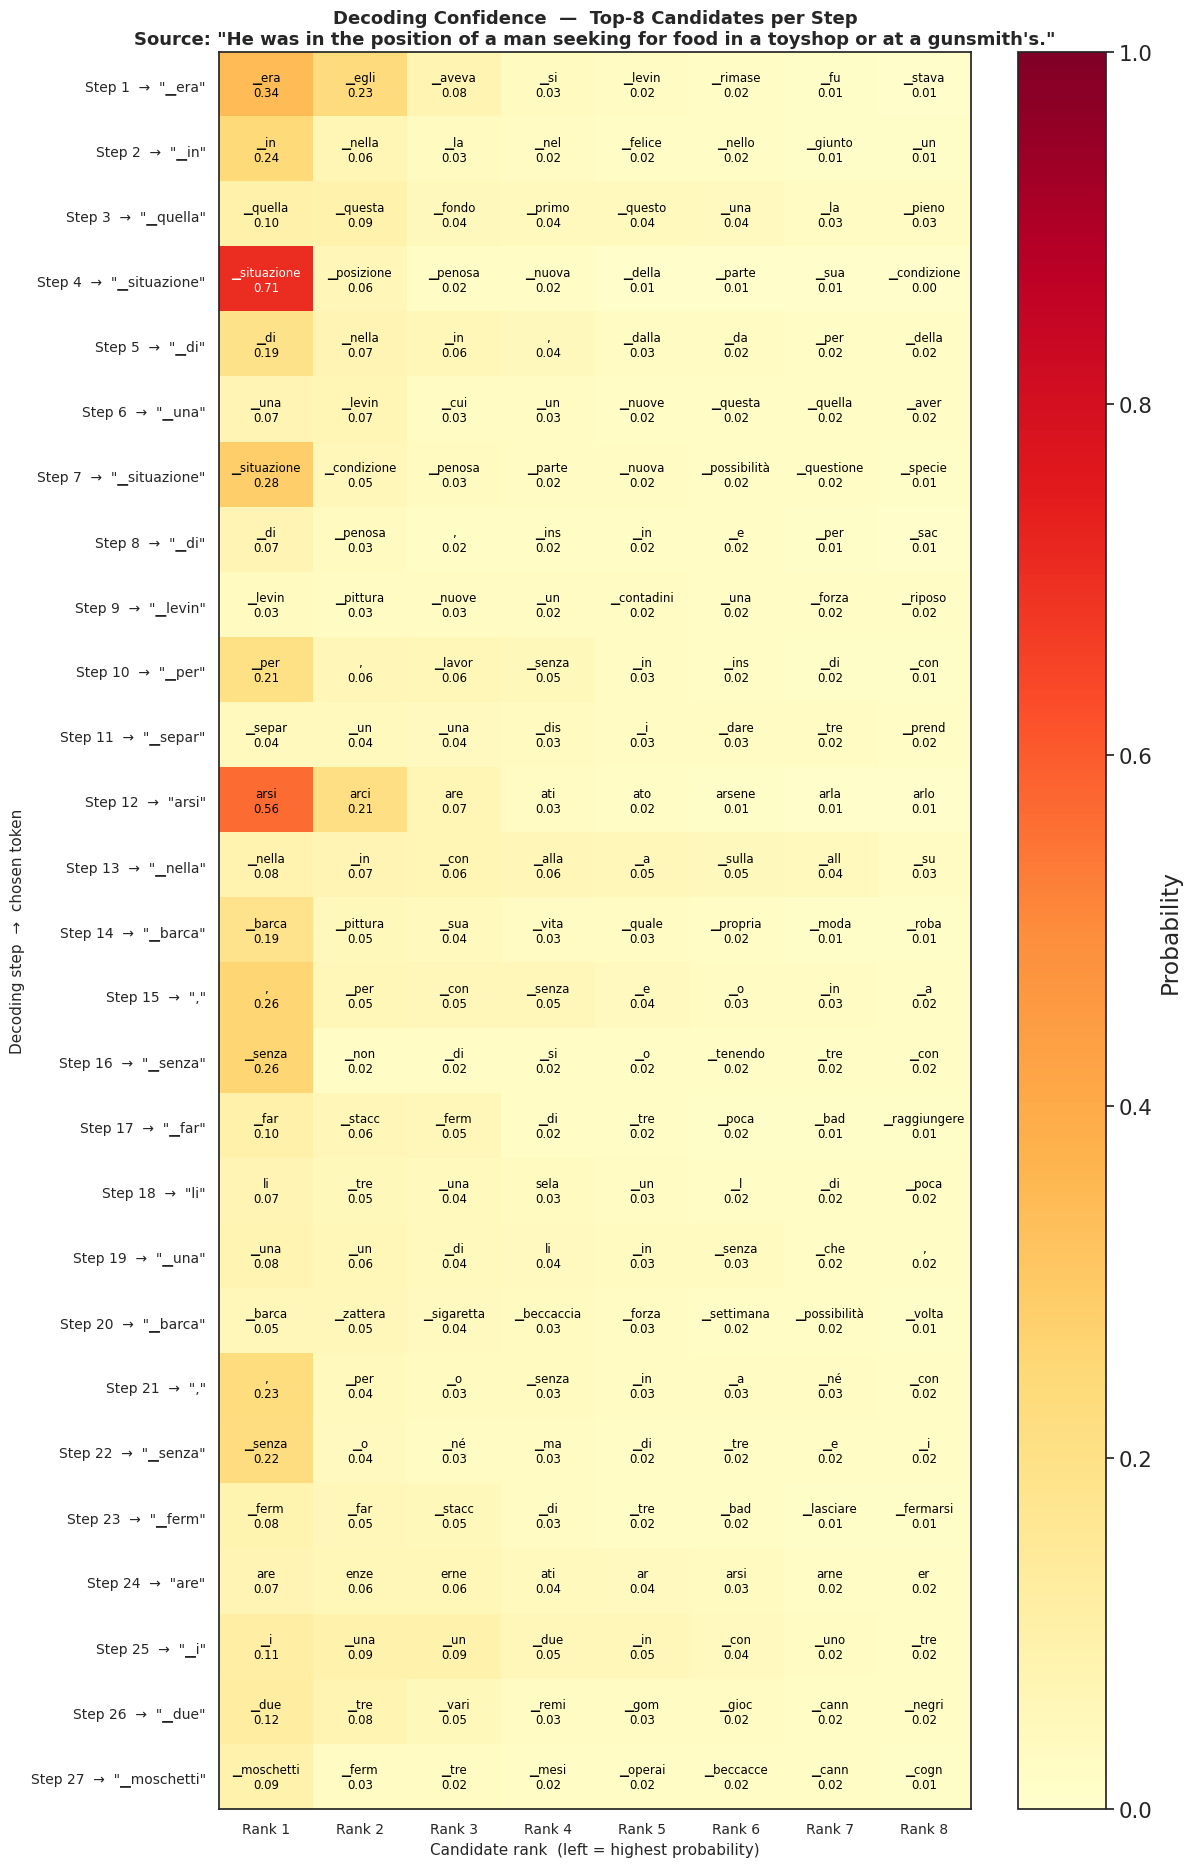

In [37]:
def plot_decoding_confidence(model: nn.Module, src_sentence: str,
                             sp: spm.SentencePieceProcessor,
                             src_seq_len: int, max_steps: int,
                             device: torch.device, top_k: int = 8) -> None:
    """
    Visualise top-k BPE candidate tokens and their probabilities at each decoding step.

    Args:
        model:        Trained Seq2SeqTransformer
        src_sentence: English sentence to translate
        sp:           Shared BPE SentencePieceProcessor
        src_seq_len:  Source sequence length
        max_steps:    Maximum decoding steps
        device:       Computation device
        top_k:        Number of top candidates to display per step
    """
    model.eval()

    src_ids = torch.tensor(
        encode_bpe(sp, src_sentence, src_seq_len), dtype=torch.long
    ).unsqueeze(0).to(device)

    src_pad_mask = (src_ids == PAD_IDX)
    with torch.no_grad():
        memory = model.encode(src_ids, src_key_padding_mask=src_pad_mask)

    generated, step_probs, step_names = [BOS_IDX], [], []

    for _ in range(max_steps):
        tgt_ids  = torch.tensor(generated, dtype=torch.long).unsqueeze(0).to(device)
        tgt_mask = nn.Transformer.generate_square_subsequent_mask(
            tgt_ids.size(1), device=device
        )
        with torch.no_grad():
            decoded = model.decode(tgt_ids, memory, tgt_mask=tgt_mask,
                                   memory_key_padding_mask=src_pad_mask)
            logits  = model.output_projection(decoded)

        probs = torch.softmax(logits[0, -1, :], dim=-1)
        top_probs, top_idxs = probs.topk(top_k)

        chosen_idx  = top_idxs[0].item()
        step_probs.append([(sp.id_to_piece(i.item()), p.item())
                           for i, p in zip(top_idxs, top_probs)])
        step_names.append(sp.id_to_piece(chosen_idx))
        generated.append(chosen_idx)

        if chosen_idx == EOS_IDX:
            break

    n_steps = len(step_probs)
    matrix  = np.zeros((n_steps, top_k))
    labels  = [[''] * top_k for _ in range(n_steps)]

    for s, candidates in enumerate(step_probs):
        for k, (word, prob) in enumerate(candidates):
            matrix[s, k] = prob
            labels[s][k] = f'{word}\n{prob:.2f}'

    fig, ax = plt.subplots(figsize=(max(10, top_k * 1.5), max(6, n_steps * 0.7)))
    im = ax.imshow(matrix, cmap='YlOrRd', aspect='auto', vmin=0, vmax=1)

    for s in range(n_steps):
        for k in range(top_k):
            ax.text(k, s, labels[s][k], ha='center', va='center',
                    fontsize=8.5,
                    color='white' if matrix[s, k] > 0.6 else 'black')

    ax.set_xticks(range(top_k))
    ax.set_xticklabels([f'Rank {i+1}' for i in range(top_k)], fontsize=10)
    ax.set_yticks(range(n_steps))
    ax.set_yticklabels([f'Step {i+1}  →  "{step_names[i]}"'
                        for i in range(n_steps)], fontsize=10)
    ax.set_title(
        f'Decoding Confidence  —  Top-{top_k} Candidates per Step\n'
        f'Source: "{src_sentence}"',
        fontsize=13, fontweight='bold'
    )
    ax.set_xlabel('Candidate rank  (left = highest probability)', fontsize=11)
    ax.set_ylabel('Decoding step  →  chosen token', fontsize=11)
    plt.colorbar(im, ax=ax, label='Probability')
    plt.tight_layout()
    plt.show()


plot_decoding_confidence(model, ex_eng, sp, SEQ_LEN_SRC, SEQ_LEN_TGT + 5,
                         device, top_k=8)

**Corpus BLEU Score Evaluation**

Token accuracy (teacher forcing) is a misleading proxy for translation quality:
the model always receives correct previous tokens, making the task artificially
easy. **BLEU** (Bilingual Evaluation Understudy) evaluates the actual
autoregressive output by measuring n-gram overlap between hypothesis and reference:

$$\text{BLEU} = BP \cdot \exp\!\left(\sum_{n=1}^{N} w_n \log p_n\right)$$

where $p_n$ is the modified n-gram precision for order $n$, $w_n = \tfrac{1}{N}$
are uniform weights, and $BP$ is a brevity penalty that discourages short outputs:

$$BP = \begin{cases} 1 & \text{if } c > r \\ e^{1 - r/c} & \text{if } c \le r \end{cases}$$

with $c$ = hypothesis length and $r$ = reference length. BLEU is computed
at the BPE subword level so partial-word matches contribute appropriately.

In [38]:
def compute_bleu(model: nn.Module, test_pairs: list[list[str]],
                 sp: spm.SentencePieceProcessor,
                 src_seq_len: int, max_steps: int,
                 device: torch.device, n_samples: int = 500) -> float:
    """
    Compute corpus BLEU score on a random sample of the test set.

    Args:
        model:       Trained Seq2SeqTransformer
        test_pairs:  [english, italian] reference pairs
        sp:          Shared BPE SentencePieceProcessor
        src_seq_len: Source sequence length
        max_steps:   Maximum decoding steps per sentence
        device:      Computation device
        n_samples:   Number of sentences to evaluate

    Returns:
        Corpus BLEU score in [0, 1]
    """
    sample     = random.sample(test_pairs, min(n_samples, len(test_pairs)))
    references, hypotheses = [], []
    smoother   = SmoothingFunction().method1

    for eng, ita in sample:
        # Both ref and hyp use the same BPE decode → comparable token lists
        ref = decode_bpe(sp, sp.encode(ita.lower())).split()
        hyp = greedy_decode(model, eng, sp, src_seq_len, max_steps, device).split()
        references.append([ref])
        hypotheses.append(hyp)

    return corpus_bleu(references, hypotheses, smoothing_function=smoother)


bleu = compute_bleu(model, test_pairs, sp, SEQ_LEN_SRC, SEQ_LEN_TGT + 5, device)
print(f"Corpus BLEU score  (500 test sentences): {bleu:.4f}")

Corpus BLEU score  (500 test sentences): 0.0189


## 🔭 **Greedy vs Beam Search Decoding**

Greedy decoding selects the single highest-probability token at every step —
fast but myopic. **Beam search** maintains *k* partial hypotheses in parallel,
exploring a richer portion of the output space before committing.

Final hypothesis scores are **length-normalised**:

$$\text{score} = \frac{\sum \log p(y_t \mid y_{<t},\,x)}{|y|^{\,\alpha}}$$

with $\alpha = 0.6$ (following Wu et al., 2016) to prevent the model from
preferring shorter outputs purely for lower accumulated negative log-prob.


Beam search k=2: BLEU = 0.0253
Beam search k=4: BLEU = 0.0202
Beam search k=8: BLEU = 0.0176

── Summary ───────────────────────────────────────────
  Greedy (k=1)     BLEU = 0.0182  ███
  Beam  (k=2)      BLEU = 0.0253  █████
  Beam  (k=4)      BLEU = 0.0202  ████
  Beam  (k=8)      BLEU = 0.0176  ███


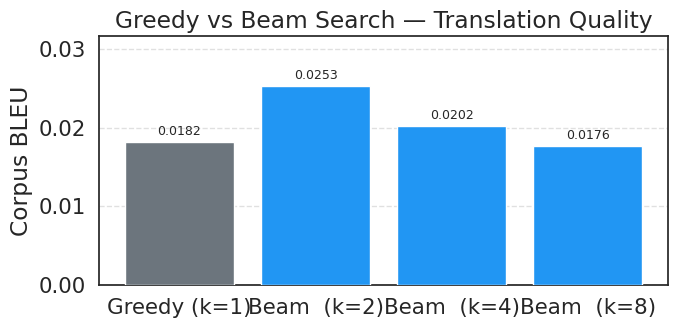

In [39]:
def compute_bleu_beam(
    model: nn.Module,
    test_pairs: list[list[str]],
    sp: spm.SentencePieceProcessor,
    src_seq_len: int,
    max_steps: int,
    device: torch.device,
    beam_size: int = 4,
    length_penalty: float = 0.6,
    n_samples: int = 500,
) -> float:
    """Corpus BLEU using beam-search decoding."""
    sample   = random.sample(test_pairs, min(n_samples, len(test_pairs)))
    smoother = SmoothingFunction().method1
    references, hypotheses = [], []

    for eng, ita in sample:
        ref = decode_bpe(sp, sp.encode(ita.lower())).split()
        hyp = beam_decode(
            model, eng, sp, src_seq_len, max_steps, device,
            beam_size=beam_size, length_penalty=length_penalty,
        ).split()
        references.append([ref])
        hypotheses.append(hyp)

    return corpus_bleu(references, hypotheses, smoothing_function=smoother)


# ── Run comparison ────────────────────────────────────────────────────────────
bleu_greedy = compute_bleu(model, test_pairs, sp, SEQ_LEN_SRC, SEQ_LEN_TGT + 5, device)

results = {"Greedy (k=1)": bleu_greedy}
for k in [2, 4, 8]:
    bleu_k = compute_bleu_beam(
        model, test_pairs, sp, SEQ_LEN_SRC, SEQ_LEN_TGT + 5, device,
        beam_size=k, length_penalty=0.6,
    )
    results[f"Beam  (k={k})"] = bleu_k
    print(f"Beam search k={k}: BLEU = {bleu_k:.4f}")

print("\n── Summary ───────────────────────────────────────────")
for name, score in results.items():
    bar = "█" * int(score * 200)
    print(f"  {name:<16} BLEU = {score:.4f}  {bar}")

# ── Bar chart ─────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 3.5))
names  = list(results.keys())
scores = list(results.values())
bars   = ax.bar(names, scores, color=["#6c757d"] + ["#2196F3"] * 3, zorder=3)
ax.bar_label(bars, fmt="%.4f", padding=3, fontsize=9)
ax.set_ylabel("Corpus BLEU")
ax.set_title("Greedy vs Beam Search — Translation Quality")
ax.set_ylim(0, max(scores) * 1.25)
ax.yaxis.grid(True, linestyle="--", alpha=0.6, zorder=0)
ax.set_axisbelow(True)
plt.tight_layout()
plt.show()


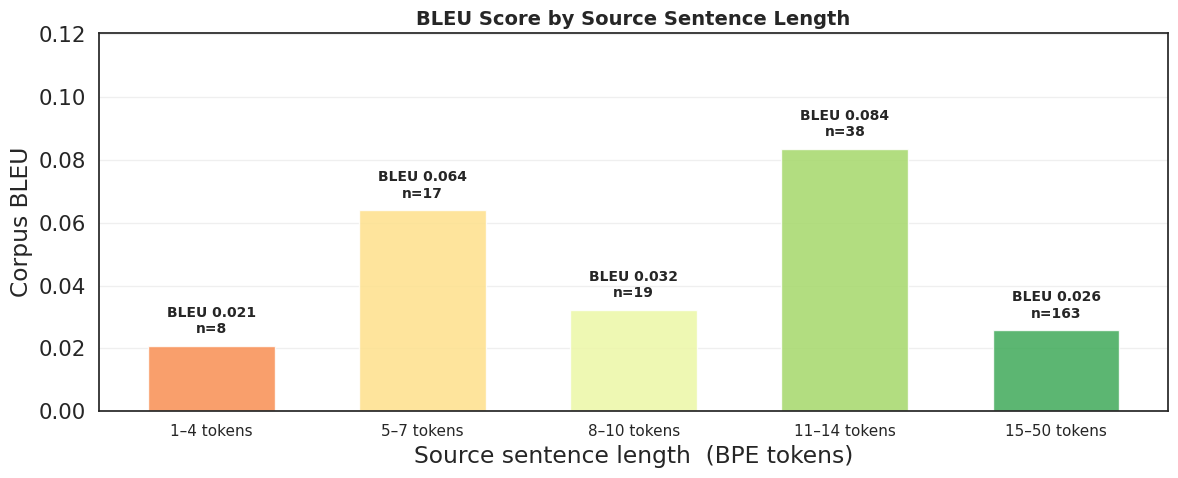

In [40]:
def plot_bleu_by_length(model: nn.Module, test_pairs: list[list[str]],
                        sp: spm.SentencePieceProcessor,
                        src_seq_len: int, max_steps: int,
                        device: torch.device,
                        n_samples: int = 300,
                        bins: list = None) -> None:
    """
    Compute and plot corpus BLEU score binned by source sentence length.

    Args:
        model:       Trained Seq2SeqTransformer
        test_pairs:  [english, italian] reference pairs
        sp:          Shared BPE SentencePieceProcessor
        src_seq_len: Source sequence length
        max_steps:   Max decoding steps
        device:      Computation device
        n_samples:   Total pairs to evaluate
        bins:        Length bin boundaries (e.g. [0, 4, 7, 10, 14, 50])
    """
    if bins is None:
        bins = [0, 4, 7, 10, 14, 50]

    smoother   = SmoothingFunction().method1
    sample     = random.sample(test_pairs, min(n_samples, len(test_pairs)))
    bin_refs   = {i: [] for i in range(len(bins) - 1)}
    bin_hyps   = {i: [] for i in range(len(bins) - 1)}

    for eng, ita in sample:
        src_len = len(sp.encode(eng.lower(), out_type=str))
        for b in range(len(bins) - 1):
            if bins[b] < src_len <= bins[b + 1]:
                bin_refs[b].append([decode_bpe(sp, sp.encode(ita.lower())).split()])
                bin_hyps[b].append(
                    greedy_decode(model, eng, sp, src_seq_len,
                                  max_steps, device).split()
                )
                break

    bleu_scores, bin_labels, bin_counts = [], [], []
    for b in range(len(bins) - 1):
        if len(bin_refs[b]) < 3:
            continue
        score = corpus_bleu(bin_refs[b], bin_hyps[b], smoothing_function=smoother)
        bleu_scores.append(score)
        bin_labels.append(f'{bins[b]+1}–{bins[b+1]} tokens')
        bin_counts.append(len(bin_refs[b]))

    x      = np.arange(len(bleu_scores))
    colors = plt.cm.RdYlGn(np.linspace(0.25, 0.85, len(bleu_scores)))

    fig, ax = plt.subplots(figsize=(12, 5))
    bars = ax.bar(x, bleu_scores, color=colors, alpha=0.85, width=0.6)
    for bar, score, count in zip(bars, bleu_scores, bin_counts):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.003,
                f'BLEU {score:.3f}\nn={count}',
                ha='center', va='bottom', fontsize=10, fontweight='bold')

    ax.set_xticks(x)
    ax.set_xticklabels(bin_labels, fontsize=11)
    ax.set_title('BLEU Score by Source Sentence Length',
                 fontsize=14, fontweight='bold')
    ax.set_xlabel('Source sentence length  (BPE tokens)')
    ax.set_ylabel('Corpus BLEU')
    ax.set_ylim(0, max(bleu_scores) * 1.2 + 0.02)
    ax.grid(alpha=0.3, axis='y')
    plt.tight_layout()
    plt.show()


plot_bleu_by_length(model, test_pairs, sp, SEQ_LEN_SRC, SEQ_LEN_TGT + 5, device)